# Matter power spectrum and line-of-sight sensitivity

Produces **`figs/matter_power.pdf`** (Fig. 8 of the paper), which puts **both**
benchmark campaigns on the same axes as the cosmological matter power spectrum.
Two subsidiary figures, **`figs/concentration.pdf`** and **`figs/scale_density.pdf`**,
plot the two concentration--mass relations whose spread sets the width of the
non-linear halo band below, and the scale densities $\rho_s(M_{200})$ they imply.
The last section adds a provisional variant, **`figs/matter_power_sub.pdf`**, which
overlays the subhalo population bound to the lens galaxy of B1422+231; no part of the
paper refers to it, and `figs/matter_power.pdf` itself is unaffected by it.

The figure shows the dimensionless matter power spectrum
$\Delta^2_\delta(k) = k^3 P_\delta(k)/2\pi^2$ over 12 decades in comoving
wavenumber, together with the projected per-mode reach of the two astrometric
channels for the two lens systems:

- **Null hypothesis, pure CDM** --- linear spectrum with no cutoff, plus its
  nonlinear one-halo continuation (band bracketing the concentration--mass
  relations of Wang+2020 and Sanchez-Conde & Prada 2014), extending the
  `halofit` spectrum (Takahashi+2012) flatly to arbitrarily high $k$.
- **Fiducial 100 GeV thermal WIMP** --- damping cutoff (acoustic damping and free
  streaming at kinetic decoupling) at $k_\mathrm{cut} \simeq 10^6\,\mathrm{Mpc}^{-1}$, its suppressed halo term, and the
  prompt cusps (Delos & White 2023) that repopulate the spectrum above it.
- **Projected sensitivity** --- the minimum detectable $\Delta^2_\delta$ *per
  $e$-fold* at wavenumber $k$, for structure spread along the line of sight at the
  mean cosmological density, in the stochastic (Eq. observable_1) and acceleration
  (Eq. observable_2) channels, for **both** systems: the galaxy lens B1422+231 at
  $\sigma_{\delta\theta} = 0.1\,\mu$as (solid) and the cluster lens
  SDSS J1029+2623 at $\sigma_{\delta\theta} = 1\,\mu$as (dashed). Both systems are
  configured through `make_system(...)` in the *Functions* section below, so the
  galaxy and cluster curves are computed by identical code.
- **Monochromatic clump overlay** --- thin curves showing the Poisson power of a
  clump population carrying a fraction $f_\mathrm{sub}$ of the mean matter density,
  easing the read-across to `figs/SNR.pdf`.

**How the sensitivity curves are built.** At each $k$ we take a white spectrum
truncated there, $P_\delta(k') = 6\pi^2\Delta^2_\delta/k^3$ for $k' < k$, normalized
so that $\Delta^2_\delta$ is the power integrated over the top $e$-fold. Folding it
through the line-of-sight integral of Eq. (C_tilde_1) --- lensing efficiency,
$(1+z)$ weighting, mean cosmological density, and $B^\mathrm{I}$ taken as the
tangential eigenvalue at the brightest image --- gives $\widetilde{C}(\omega)$ in
closed form (`I_M`, `C_pq`). Inverting "signal = noise" then gives the plotted
threshold: for the stochastic channel, $\widetilde{C}(2\pi/\tau)$ against the white
floor of Eq. (noise_1) at the single lowest accessible mode; for the acceleration
channel, the smeared $\omega^4$ moment of Eq. (observable_2) against Eq. (noise_2).
Both are instrument-limited (no stellar residual) and evaluated in the point-source
limit. See App. Matter Power Spectrum of the paper.

**Inputs.** `Delta2_output.csv` and `Delta2_extended_output.csv`, the CLASS +
`halofit` spectra written by `Pnl.ipynb`. They are committed to the repository, so
this notebook runs without a CLASS installation.

*Runtime: ~1 minute.*

# Setup

## Packages

In [1]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
from astropy.cosmology import FlatLambdaCDM
# Cosmology is set in the Parameters cell below (H0 = 70, Om0 = 0.3, matching both
# params_* modules and Sec. I of the paper); it is used here for distances and rho_m,0.

In [2]:
colors = sns.color_palette(xgfs_fancy6); colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

## Parameters

In [3]:
import params_B1422_231 as pB
import params_J1029_2623 as pJ
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)   # cosmology used by both params modules

# fiducial ten-year campaign (both benchmark systems)
tau = 10 * year
N_obs = 300

# --- galaxy lens: B1422+231, observed with EPIC (sigma_delta_theta = 0.1 muas) ---
# tangential eigenvalue of B^I for the brightest image of the bright A,B pair
# (macro_lens.ipynb), and the BULK fiducial |v_L| ~ 865 km/s (macro-magnified;
# the halo internal dispersion enters unmagnified -- kinematics fix; params_B1422_231).
eigvals_B1422 = np.load('macro_lens_results.npz')['eigvals_fit']
B_tang_gal     = np.max(np.abs(eigvals_B1422[1]))   # image B, tangential |B| ~ 10.2
v_gal     = np.linalg.norm(pB.v_lens_fid)      # ~ 865 km/s (bulk)
sigma_dtheta_gal = 0.1 * muas                         # EPIC-class relative astrometry

# --- cluster lens: SDSS J1029+2623, at sigma_delta_theta = 1 muas ---
# Acebron+2022 macro-model; EFFECTIVE fiducial |v_L| ~ 552 km/s (macro-magnified):
# bulk 474 km/s (+) the moving-clump member-halo term sqrt(2)*f_gal*sigma_v; the
# microhalos' own dispersion enters unmagnified -- see params_J1029_2623.
B_tang_clu     = np.max(np.abs(pJ.eigvals_fit[2]))  # bright image C, tangential |B| ~ 22.6
v_clu     = np.linalg.norm(pJ.v_lens_fid)      # ~ 552 km/s (effective)
sigma_dtheta_clu = 1.0 * muas                         # conservative light-centroiding precision

# Critical surface densities, kept as a cross-check on the strong-lensing boundary below:
# the old single-plane criterion ("one structure reaches Sigma_cr") is the chi -> chi_L
# limit of the Limber kernel W(chi) of make_system, since W(chi_L) = rho_m,0 (1+z_L)^2/Sigma_cr.
Sigma_crit_gal = Sigma_crit(pB.d_lens, pB.d_source, pB.d_lens_source)
Sigma_crit_clu = Sigma_crit(pJ.d_lens, pJ.d_source, pJ.d_lens_source)
print('Sigma_crit = %.4g (galaxy), %.4g (cluster) M_Solar/pc^2'
      % (Sigma_crit_gal/(M_Solar/pc**2), Sigma_crit_clu/(M_Solar/pc**2)))

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.040 muas = 0.195e-12 rad
theta_E_star =  1.400 muas
sigma_SIS = 183 km/s, R_200^G = 310 kpc, M_200^G = 4.8e+12 M_Solar
x_sub (projected / LOS-weighted median): A 0.016/0.031, B 0.015/0.030, C 0.017/0.033, D 0.004/0.013
R_200^cluster = 973 kpc, x_sub = 0.133 (projected 0.098)
Sigma_crit = 2072 (galaxy), 2028 (cluster) M_Solar/pc^2


## Import Data

In [4]:
data = np.loadtxt("Delta2_output.csv", delimiter=",", skiprows=1)  # skip header
kk, k_h, D2_lin, D2_nl = data.T

data = np.loadtxt("Delta2_extended_output.csv", delimiter=",", skiprows=1)  # skip header
kk_ext, k_h_ext, D2_lin_ext, D2_nl_ext, D2_nl_30 = data.T

# Sensitivity

## Functions

In [5]:
def make_system(params, B_tang, v_lens, sigma_delta_theta, label, ls):
    """Bundle everything the per-mode sensitivity needs for one lens + instrument setup.

    B_tang is the tangential eigenvalue B_t^I of B^I; the line-of-sight grid runs in comoving
    distance from the observer out to that system's source redshift.  K_S is the Limber
    kernel of the convergence, used for the strong-lensing boundary of the figure.
    """
    vec_a = np.logspace(np.log10(0.999), np.log10(1/(1 + params.z_source)), int(1e4))
    vec_z = 1 / vec_a - 1
    vec_D = cosmo.angular_diameter_distance(vec_z).value * Mpc * (1 + vec_z)  # comoving distance
    # Limber kernel of the convergence, kappa(theta) = int dchi W(chi) delta(chi theta, chi) with
    #     W(chi) = 4 pi G rho_bar a^2 chi (chi_S - chi)/chi_S,
    # i.e. the same line-of-sight integrand as C_pq, with one power of chi in place of the
    # angular kernel I_M. K_S = int dchi W^2 (dimension 1/length) fixes the strong-lensing
    # boundary; Lambda_S = chi_S K_S is its dimensionless form.
    vec_W = (4 * np.pi * G_N * rho_M_0 / vec_a) * vec_D * (1 - vec_D / params.D_source)
    K_S = np.trapezoid(vec_W**2, vec_D)
    # Sweep rate mu_sweep = sqrt(|B^I mu|^2 + mu_L^2): the bulk motion is magnified by B^I,
    # the subhalos' own orbital motion mu_L is not (footnote to Sec. II C).
    mu_tilde = np.sqrt((B_tang * v_lens / params.D_lens)**2 + params.mu_L_int**2)
    return dict(label=label, ls=ls, B_tang=B_tang, v_lens=v_lens, mu_tilde=mu_tilde,
                D_lens=params.D_lens, D_source=params.D_source, K_S=K_S,
                sigma_delta_theta=sigma_delta_theta, vec_a=vec_a, vec_D=vec_D)

sys_gal = make_system(pB, B_tang_gal, v_gal, sigma_dtheta_gal, r'B1422+231 (galaxy) + EPIC, 0.1 muas', 'solid')
# Worst-case post-subtraction stellar microlensing residual in the acceleration channel
# (Sec. III C; see impact_numbers.py): unfitted-star bound plus fitted-star residual,
# rescaled to N = 300, tau = 10 yr, image-A budget adopted per image and doubled for the
# pair. Recorded for reference only -- every curve in this figure is instrument-limited,
# so that the two channels can be compared on equal footing (see the acceleration cell).
sys_gal['sigma2_acc_star'] = 2 * 1.29e-5 * muasyy**2
sys_clu = make_system(pJ, B_tang_clu, v_clu, sigma_dtheta_clu, r'SDSS J1029+2623 (cluster), 1 muas', (0,(5,2)))
systems = [sys_gal, sys_clu]

for s in systems:
    # measurement noise on the fitted proper motion and acceleration, sigma_theta_dot and
    # sigma_theta_ddot of App. Proper Motion & Acceleration Estimators (Eq. noise_2 is the
    # square of the latter)
    s['sigma_theta_dot']  = 2*np.sqrt(3)  * s['sigma_delta_theta'] / np.sqrt(N_obs * tau**2)
    s['sigma_theta_ddot'] = 12*np.sqrt(5) * s['sigma_delta_theta'] / np.sqrt(N_obs * tau**4)
    print('%-36s B_tang = %5.2f, |v_L| = %4.0f km/s, mu_tilde = %.2f muas/yr, sigma = %.1f muas'
          % (s['label'], s['B_tang'], s['v_lens']/(km/second), s['mu_tilde']/muasy,
             s['sigma_delta_theta']/muas))
    print('%-36s sigma_theta_dot = %.2g muas/yr, sigma_theta_ddot = %.2g muas/yr^2'
          % ('', s['sigma_theta_dot']/muasy, s['sigma_theta_ddot']/muasyy))

B1422+231 (galaxy) + EPIC, 0.1 muas  B_tang = 10.19, |v_L| =  865 km/s, mu_tilde = 1.39 muas/yr, sigma = 0.1 muas
                                     sigma_theta_dot = 0.002 muas/yr, sigma_theta_ddot = 0.0015 muas/yr^2
SDSS J1029+2623 (cluster), 1 muas    B_tang = 22.62, |v_L| =  552 km/s, mu_tilde = 1.22 muas/yr, sigma = 1.0 muas
                                     sigma_theta_dot = 0.02 muas/yr, sigma_theta_ddot = 0.015 muas/yr^2


### Strong lensing regime

In [6]:
def Delta2_strong_lens(k, sys):
    """Boundary of the hatched strong-lensing region of Fig. matter_power.

    A statistical, per-e-fold criterion, in the same convention as the sensitivity curves
    of this notebook rather than a statement about one object. Inserting the truncated
    white template of I_M, P_delta(k') = 6 pi^2 Delta2 k^-3 for k' < k, into the Limber
    variance of the convergence,

        <kappa^2> = K_S int d^2k_perp/(2 pi)^2 P_delta(k_perp) = (3 pi/2) Delta2 K_S / k,

    with K_S = int dchi W^2 the kernel built in make_system. Setting <kappa^2> = 1 gives
    the boundary below: above it, a single e-fold of power at k already drives the rms
    convergence to the source past unity, so the weak-lensing (linear deflection)
    treatment of Eq. (C_tilde_1) no longer applies.

    Two O(1) caveats. Including the shear, <kappa^2 + |gamma|^2> = 2 <kappa^2> = 1, would
    lower the boundary by a factor 2. And for a strongly non-Gaussian field the rms and
    the strong-lensing cross-section are not the same statistic.

    The boundary depends on the source distance (roughly as chi_S^-3), so the two systems
    do not coincide: the cluster sightline sits a factor ~3 above the galaxy one. The
    figure hatches above the galaxy (deeper, lower) edge. The single-plane criterion in
    terms of Sigma_cr is the chi -> chi_L limit of the same kernel,
    W(chi_L) = rho_m,0 (1+z_L)^2 / Sigma_cr, checked below.
    """
    return 2 * k / (3 * np.pi * sys['K_S'])


for s, p, Sig, name in [(sys_gal, pB, Sigma_crit_gal, 'B1422+231 (galaxy)'),
                        (sys_clu, pJ, Sigma_crit_clu, 'SDSS J1029+2623 (cluster)')]:
    W_L = (4*np.pi*G_N*rho_M_0*(1 + p.z_lens)) * p.D_lens * (1 - p.D_lens/p.D_source)
    print('%-26s chi_S = %4.0f Mpc, K_S = %.4g Mpc^-1, Lambda_S = %.4f'
          % (name, p.D_source/Mpc, s['K_S']*Mpc, s['K_S']*p.D_source))
    print('%-26s Delta2_SL = %.3g x k[h/Mpc]' % ('', Delta2_strong_lens(cosmo.h*Mpc**-1, s)))
    print('%-26s Sigma_cr cross-check: rho_m,0 (1+z_L)^2 / W(chi_L) = %.4g vs %.4g M_Solar/pc^2'
          % ('', rho_M_0*(1 + p.z_lens)**2/W_L/(M_Solar/pc**2), Sig/(M_Solar/pc**2)))


B1422+231 (galaxy)         chi_S = 6891 Mpc, K_S = 3.285e-05 Mpc^-1, Lambda_S = 0.2264
                           Delta2_SL = 4.52e+03 x k[h/Mpc]
                           Sigma_cr cross-check: rho_m,0 (1+z_L)^2 / W(chi_L) = 2072 vs 2072 M_Solar/pc^2
SDSS J1029+2623 (cluster)  chi_S = 5455 Mpc, K_S = 1.129e-05 Mpc^-1, Lambda_S = 0.0616
                           Delta2_SL = 1.32e+04 x k[h/Mpc]
                           Sigma_cr cross-check: rho_m,0 (1+z_L)^2 / W(chi_L) = 2028 vs 2028 M_Solar/pc^2


### Power spectral density

In [7]:
def I_M(omega, mu_tilde, X, k, Delta2):
    """Angular kernel int dphi/2pi M_11 P_delta of Eq. (C_tilde_1), for a WHITE spectrum
    truncated at wavenumber k:

        P_delta(k') = 6 pi^2 Delta2 / k^3   for k' < k,   0 above.

    That normalization makes Delta2 the power integrated over the top e-fold,
    int_{k/e}^{k} Delta^2_delta dln k' = (1 - e^-3) Delta2 ~ Delta2, which is what the
    figure's y axis compares against the predicted spectra. (Note this is NOT a
    scale-invariant spectrum: Delta^2_delta(k') = 3 Delta2 (k'/k)^3 below the cutoff.)

    Eq. (C_tilde_1) evaluates P_delta at k_perp = |omega|/(mu_tilde X cos phi), so the
    truncation admits only |phi| < arccos(x) with x = k_perp,min/k = omega/(mu_tilde X k),
    and the phi integral is elementary:
        int_{|phi| < arccos x} dphi/2pi cos^2 phi = [arccos x + x sqrt(1-x^2)]/2pi.
    X is the comoving sweep lever arm sweep_offplane(chi) -- the beam's transverse velocity
    at that plane is mu_tilde X, which equals chi mu_tilde only up to the lens plane and
    falls back to zero on the source (notes/off_plane_los_kernel.md). All lengths comoving,
    matching the comoving k of the input spectra.
    """
    k_perp_min = omega / (mu_tilde * np.maximum(X, 1e-30))
    x = k_perp_min / k
    result = np.zeros_like(x, dtype=float)
    mask = (x <= 1)
    result[mask] = (
        3 * np.pi * Delta2 / k**3
        * (np.arccos(np.clip(x[mask], -1, 1)) + x[mask] * np.sqrt(1 - x[mask]**2))
    )
    return result

In [8]:
def C_pq(omega, sys, k, Delta2):
    """Astrometric PSD C~^I_pq(omega) of Eq. (C_tilde_1) for the truncated white spectrum
    of I_M, for the lens/instrument configuration `sys` (see make_system).

    The comoving line-of-sight integral carries the lensing efficiency [(D_S - D)/D_S]^2
    and the Poisson factor (4 pi G rho_bar a^2)^2 = (4 pi G rho_m,0 (1+z))^2 of
    App. Matter Power Spectrum, at the MEAN cosmological density -- i.e. field halos only,
    with no enhancement from the overdense lens environment. B^I is applied as the scalar
    tangential eigenvalue B_t^I rather than the full tensor, giving the component of C~ along the
    image motion (the dominant one). No source form factor: this is the point-source limit.

    Both off-plane (multi-plane) corrections of notes/off_plane_los_kernel.md live INSIDE the
    integral: the amplification B_offplane(chi), which falls from B_t^I at the lens plane to 1
    at the observer, and the sweep lever arm sweep_offplane(chi), which falls back to zero on
    the source. Both are exact at chi = chi_L, so the lens-bound forecasts are unaffected.

    If sys carries a 'slab' key (D_L, a_L, ell), the population is instead confined to the
    lens plane, modeled as a comoving path ell of mean-density universe placed at D_L. There
    sweep_offplane(D_L) = D_L and B_offplane(D_L) = B_t^I identically, so this branch is free
    of the multi-plane approximation altogether.
    """
    if sys.get('slab') is not None:
        D_L, a_L, ell = sys['slab']
        return sys['B_tang']**2 * 4/omega * ell * (
            (1 - D_L/sys['D_source'])**2
            * I_M(omega, sys['mu_tilde'], np.atleast_1d(D_L), k, Delta2)[0]
            * (4 * np.pi * G_N * rho_M_0 / a_L)**2)
    X = sweep_offplane(sys['vec_D'], sys['D_lens'], sys['D_source'])
    B_eff = B_offplane(sys['vec_D'], sys['D_lens'], sys['D_source'], sys['B_tang'])
    prefac = 4 / omega
    integrand = (B_eff**2
                 * (1 - sys['vec_D']/sys['D_source'])**2
                 * I_M(omega, sys['mu_tilde'], X, k, Delta2)
                 * (4 * np.pi * G_N * rho_M_0 / sys['vec_a'])**2  # rho_bar(z) a^2 = rho_m,0 (1+z)
    )
    integral = np.trapezoid(integrand, sys['vec_D'])
    return prefac * integral

def C_pq_vectorized(vec_omega, sys, k, Delta2):
    return np.asarray([C_pq(w, sys, k, Delta2) for w in np.atleast_1d(vec_omega)])

### Proper motion and acceleration functions

In [9]:
# Smearing form factors F_1, F_2 of App. Proper Motion & Acceleration Estimators, which
# correct the ideal omega^2 / omega^4 derivative weights for the finite fit window tau.
# Both -> 1 as omega tau -> 0 and roll off as (omega tau)^-4 / (omega tau)^-6 above it;
# the heaviside pair just switches to the small-argument limit below omega tau = 1e-2.
def smear_F1(a):
    return np.heaviside(-a + 1e-2,1) + np.heaviside(a - 1e-2,0) * 144 * (a * np.cos(a/2) - 2 * np.sin(a/2))**2 / a**6
def smear_F2(a):
    return np.heaviside(-a + 1e-2,1) + np.heaviside(a - 1e-2,0) * 14400 * (6 * a * np.cos(a/2) + (-12 + a**2) * np.sin(a/2))**2 / a**10

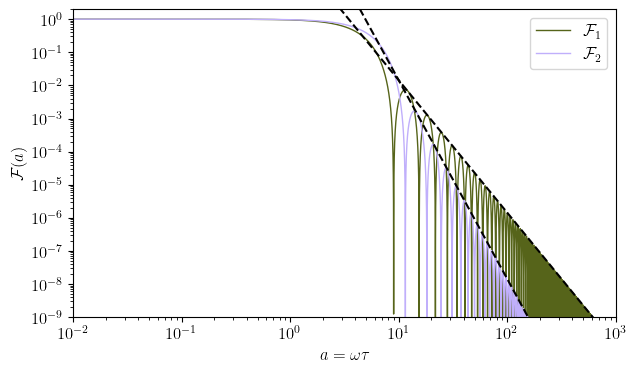

In [10]:
fig,ax = plt.subplots(1,1,figsize=(7,4))
x = np.logspace(-2,3,int(1e5))
ax.plot(x, smear_F1(x), label=r'$\mathcal{F}_1$', color=colors[0], lw=1)
ax.plot(x, smear_F2(x), label=r'$\mathcal{F}_2$', color=colors[1], lw=1)
ax.plot(x,144 * x**-4,'--k')
ax.plot(x,14400 * x**-6,'--k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a = \omega \tau$')
ax.set_ylabel(r'$\mathcal{F}(a)$')
ax.set_xlim(1e-2, 1e3)
ax.set_ylim(1e-9, 2)
ax.legend(loc='upper right', fontsize=12);

In [11]:
def sigma2_acc_signal(tau, sys, k, Delta2):
    """Differential acceleration variance of Eq. (observable_2) for the LOS spectrum above:
    the smeared omega^4 moment of C~, int domega/2pi C~ omega^4 F_2(omega tau).

    The grid deliberately reaches eight decades BELOW the band edge 2 pi/tau, where the
    omega^4 F_2 kernel peaks. The factor 2 counts the negative frequencies, since C~ is a
    two-sided PSD (as in sensitivity.ipynb, impact_numbers.py, cusp_snr.py,
    los_full_spectrum_snr.py, los_vs_lens_decomposition.py).
    """
    omega_ref = 2 * np.pi / tau
    vec_omega = omega_ref * np.logspace(-8,2,2000)
    vec_C = C_pq_vectorized(vec_omega, sys, k=k, Delta2=Delta2)
    integrand = 2 * (2*np.pi)**(-1) * vec_C * vec_omega**4 * smear_F2(vec_omega * tau)
    integral = np.trapezoid(integrand, vec_omega)
    return integral

In [12]:
%timeit sigma2_acc_signal(tau=tau, sys=sys_gal, k=1e8*Mpc**-1, Delta2=1)

276 ms ± 24 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Power spectral density

In [13]:
# STOCHASTIC channel (Eq. observable_1). Minimum detectable Delta2 per e-fold: the signal
# PSD in the lowest accessible DFT mode, omega_min = 2 pi/tau, must reach the white
# instrumental noise of Eq. (noise_1). Only this one mode is used -- the spectrum is red and
# the truncation puts little power at higher harmonics -- so this is a per-mode threshold,
# deliberately more conservative than an optimally weighted sum over modes.
omega_min = 2 * np.pi / tau
vec_k_stoch = np.logspace(5,10,int(1e4)) * Mpc**-1

for s in systems:
    # 1.001*omega_min stays just inside the measurable band (C_inst is a step at omega_min)
    C_noise = C_inst(omega=1.001*omega_min, tau=tau, N_obs=N_obs,
                     sigma_delta_theta=s['sigma_delta_theta'])
    Delta2_stoch = np.full(len(vec_k_stoch), np.nan)
    for i, k in enumerate(vec_k_stoch):
        C_signal = C_pq(omega=omega_min, sys=s, k=k, Delta2=1)   # C~ is linear in Delta2
        if C_signal > 0:
            Delta2_stoch[i] = C_noise / C_signal
    s['Delta2_stoch'] = Delta2_stoch
    i_min = int(np.nanargmin(Delta2_stoch))
    print('%-36s stoch. min Delta^2 = %.3g at k = %.3g h/Mpc'
          % (s['label'], Delta2_stoch[i_min], vec_k_stoch[i_min]/(cosmo.h*Mpc**-1)))

B1422+231 (galaxy) + EPIC, 0.1 muas  stoch. min Delta^2 = 9.06e+05 at k = 1.45e+08 h/Mpc


SDSS J1029+2623 (cluster), 1 muas    stoch. min Delta^2 = 1.19e+07 at k = 9.88e+07 h/Mpc


## Proper Motion and Acceleration

In [14]:
# ACCELERATION channel (Eq. observable_2). Minimum detectable Delta2 per e-fold: the
# stochastic contribution to the fitted differential acceleration must reach the
# measurement noise of Eq. (noise_2), 720 sigma_delta_theta^2/(N tau^4).
vec_k_acc = np.logspace(-1,10,int(120)) * Mpc**-1

for s in systems:
    # Instrument-limited, like the stochastic curve above, so the two channels are compared
    # on the same footing. The stellar residual (s['sigma2_acc_star']) is a smooth,
    # near-quadratic trend and so would burden only this channel; it is left out here and
    # shown instead in Figs. acc and SNR.
    sigma2_acc_noise = 720 * s['sigma_delta_theta']**2 / (tau**4 * N_obs)
    Delta2_acc = np.zeros_like(vec_k_acc, dtype=float)
    for i, k in enumerate(vec_k_acc):
        sigma2_acc_signal_1 = sigma2_acc_signal(tau=tau, sys=s, k=k, Delta2=1)
        if sigma2_acc_signal_1 > 0:
            Delta2_acc[i] = sigma2_acc_noise / sigma2_acc_signal_1
    s['Delta2_acc'] = Delta2_acc
    i_min = int(np.argmin(np.where(Delta2_acc > 0, Delta2_acc, np.inf)))
    print('%-36s sigma_theta_ddot = %.2g muas/yr^2, acc. min Delta^2 = %.3g at k = %.3g h/Mpc'
          % (s['label'], np.sqrt(sigma2_acc_noise)/muasyy,
             Delta2_acc[i_min], vec_k_acc[i_min]/(cosmo.h*Mpc**-1)))

B1422+231 (galaxy) + EPIC, 0.1 muas  sigma_theta_ddot = 0.0015 muas/yr^2, acc. min Delta^2 = 8.03e+05 at k = 8.64e+07 h/Mpc


SDSS J1029+2623 (cluster), 1 muas    sigma_theta_ddot = 0.015 muas/yr^2, acc. min Delta^2 = 1.1e+07 at k = 6.98e+07 h/Mpc


## Non-linear matter power spectrum (CDM)

Fiducial estimate of the small-scale non-linear matter power spectrum within standard cold dark matter:
1. a Press--Schechter / halo-model one-halo term (Sheth--Tormen mass function, NFW profiles), shown as a band spanning the halo concentration--mass relation from the (pessimistic) universal relation of Wang et al. 2020 to the (more optimistic) flattened relation of Sanchez-Conde & Prada 2014, and
2. prompt cusps (Delos & White 2023).


In [15]:
# --- background densities (natural units) ---
# rho_M_0 (mean matter density today) and rho_crit come from natural_units_GeV, which
# is built on the same H_0 = 70 km/s/Mpc, Om0 = 0.3 as the astropy cosmology above.
# Do not redefine them here: a second spelling of rho_m,0 in this namespace is exactly
# the kind of collision this notebook has to avoid. r_200(M) likewise comes from
# sensitivity_functions.
delta_c    = 1.686                                                                  # spherical-collapse threshold

# --- fiducial dark-matter damping cutoff ---
# thermal WIMP with m_chi = 100 GeV, T_kd = 30 MeV  ->  k_cut ~ 1.06e6 / Mpc  (Delos & White 2023).
# Delos & White label this a free-streaming scale; in the mass convention below it lands on the
# ACOUSTIC-damping mass M_ao ~ 4e-6 M_sun (the DM mass in the comoving horizon at T_kd), which is
# the larger of the two damping scales for m_chi/T_kd ~ 3e3 and hence the physical cutoff.
k_cut = 1.06e6 * Mpc**-1
M_cut = (4 * np.pi / 3) * rho_M_0 * (np.pi / k_cut)**3                                # damping cutoff mass
print('M_cut = %.2e M_sun   (k_cut = %.2e / Mpc)' % (M_cut / M_Solar, k_cut * Mpc))

# --- linear dimensionless power spectrum (extended CDM, optional damping cutoff) ---
_int_lnD2lin = interp1d(np.log(kk_ext), np.log(D2_lin_ext), bounds_error=False,
                        fill_value=(np.log(D2_lin_ext[0]), np.log(D2_lin_ext[-1])))
def Delta2_lin(k, cutoff=True):
    """Linear Delta^2(k); k in natural units. Damping cutoff multiplies the power by exp[-2 (k/k_cut)^2]."""
    out = np.exp(_int_lnD2lin(np.log(k * Mpc)))
    return out * np.exp(-2 * (k / k_cut)**2) if cutoff else out

# --- variance on a mass scale M (real-space top-hat) ---
def _W_tophat(x):
    x = np.asarray(x, float); w = np.ones_like(x); g = x > 1e-3; xx = x[g]
    w[g] = 3 * (np.sin(xx) - xx * np.cos(xx)) / xx**3
    return w
def R_lagrangian(M):
    return (3 * M / (4 * np.pi * rho_M_0))**(1 / 3)                                 # comoving Lagrangian radius
def sigma_of_M(M, cutoff=True):
    R = R_lagrangian(M)
    integrand = lambda lk: Delta2_lin(np.exp(lk) * Mpc**-1, cutoff) * _W_tophat(np.exp(lk) * Mpc**-1 * R)**2
    return np.sqrt(quad(integrand, np.log(1e-4), np.log(1e11), limit=400)[0])

# tabulate sigma(M) and its logarithmic derivative, with (WIMP) and without (pure CDM) the cutoff
vec_M_sig = np.logspace(-14, 16, 150) * M_Solar
_int_lnsig = {}
for _cut in (True, False):
    _vec_sigma = np.array([sigma_of_M(M, cutoff=_cut) for M in vec_M_sig])
    _int_lnsig[_cut] = interp1d(np.log(vec_M_sig), np.log(_vec_sigma), fill_value='extrapolate')
def sigma_M(M, cutoff=True):  return np.exp(_int_lnsig[cutoff](np.log(M)))
def dlnsigma_dlnM(M, cutoff=True):
    h = 1e-3
    return (np.log(sigma_M(M * np.exp(h), cutoff)) - np.log(sigma_M(M * np.exp(-h), cutoff))) / (2 * h)

# --- linear growth factor D(a) and collapse redshift z_coll(M), where sigma(M) D(a_coll) = delta_c ---
def _growth_unnorm(a):
    Om, OL = cosmo.Om0, 1 - cosmo.Om0
    return 2.5 * Om * np.sqrt(Om / a**3 + OL) * quad(lambda ap: (Om / ap**3 + OL)**-1.5 / ap**3, 1e-8, a)[0]
_D_norm = _growth_unnorm(1.0)
_a_grid = np.logspace(-4, 0, 400); _D_grid = np.array([_growth_unnorm(a) / _D_norm for a in _a_grid])
_int_a_of_D = interp1d(_D_grid, _a_grid, bounds_error=False, fill_value=(_a_grid[0], _a_grid[-1]))
def z_collapse(M, cutoff=True):
    D = delta_c / sigma_M(M, cutoff)
    return 1 / float(_int_a_of_D(D)) - 1 if D < 1 else 0.0
_int_zc = {}
for _cut in (True, False):
    _vec_zc = np.array([z_collapse(M, _cut) for M in vec_M_sig])
    _int_zc[_cut] = interp1d(np.log(vec_M_sig), _vec_zc, bounds_error=False,
                             fill_value=(_vec_zc[0], _vec_zc[-1]))
def z_coll_M(M, cutoff=True): return float(_int_zc[cutoff](np.log(M)))

# --- Sheth-Tormen halo mass function dn/dlnM ---
def dn_dlnM(M, cutoff=True):
    nu = delta_c / sigma_M(M, cutoff)
    A_ST, a_ST, p_ST = 0.3222, 0.707, 0.3
    nu_p = np.sqrt(a_ST) * nu
    f_nu = A_ST * np.sqrt(2 / np.pi) * nu_p * np.exp(-nu_p**2 / 2) * (1 + nu_p**(-2 * p_ST))
    return (rho_M_0 / M) * f_nu * abs(dlnsigma_dlnM(M, cutoff))

print('M = 1e-6 Msun:  sigma = %.2f (WIMP) | %.2f (pure CDM), z_coll = %.1f | %.1f'
      % (sigma_M(1e-6 * M_Solar), sigma_M(1e-6 * M_Solar, cutoff=False),
         z_coll_M(1e-6 * M_Solar), z_coll_M(1e-6 * M_Solar, cutoff=False)))
print('M = 1e+0 Msun:  sigma = %.2f, z_coll = %.1f' % (sigma_M(1e0  * M_Solar), z_coll_M(1e0  * M_Solar)))

M_cut = 4.46e-06 M_sun   (k_cut = 1.06e+06 / Mpc)


/var/folders/4c/r0fv34l54990y0356vhxlw7c0000gn/T/ipykernel_39624/2662408446.py:36: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return np.sqrt(quad(integrand, np.log(1e-4), np.log(1e11), limit=400)[0])


M = 1e-6 Msun:  sigma = 15.01 (WIMP) | 15.38 (pure CDM), z_coll = 10.4 | 10.7
M = 1e+0 Msun:  sigma = 12.44, z_coll = 8.5


In [16]:
# --- one-halo (Press-Schechter / halo-model) non-linear power spectrum with NFW profiles ---
# concentration-mass relation: extrapolations to substellar masses differ widely, so the
# prediction is bracketed by two published relations:
#   lower edge: Wang et al. 2020 universal (Einasto) relation -- the least concentrated
#   upper edge: Sanchez-Conde & Prada 2014 flattened relation -- roughly 2x higher c at M_cut
# WIMP variants are truncated near the cutoff mass with the Wang et al. 2020
# suppression factor exp[-0.529 (M_cut/M)^(1/3)]; pure-CDM variants carry no cutoff.
def conc_Wang(M):
    return np.clip(c_Einasto(M, h=cosmo.h, M_cut=M_cut), 2, 200)
def conc_Wang_nocut(M):
    return np.clip(c_Einasto(M, h=cosmo.h), 2, 200)

_scp14_coeff = [37.5153, -1.5093, 1.636e-2, 3.66e-4, -2.89237e-5, 5.32e-7]
def _scp14_pol(M):
    x = np.log(M / (cosmo.h**-1 * M_Solar))
    return sum(ci * x**i for i, ci in enumerate(_scp14_coeff))
def conc_SCP14(M):
    """Sanchez-Conde & Prada 2014 (Eq. 1) c_200(M, z=0)."""
    return np.clip(np.exp(-0.529 * (M_cut / M)**(1/3)) * _scp14_pol(M), 2, 200)
def conc_SCP14_nocut(M):
    return np.clip(_scp14_pol(M), 2, 200)

def u_NFW(k, M, conc):
    """Normalized Fourier transform of an NFW halo of mass M (u -> 1 as k -> 0)."""
    c = conc(M); r_s = r_200(M) / c; x = k * r_s
    mc = np.log(1 + c) - c / (1 + c)
    si,  ci  = sp.special.sici(x)
    si1, ci1 = sp.special.sici((1 + c) * x)
    return (np.sin(x) * (si1 - si) + np.cos(x) * (ci1 - ci) - np.sin(c * x) / ((1 + c) * x)) / mc

_lnM_1h = np.log(np.logspace(-13, 16, 290) * M_Solar)
def Delta2_PS(k, conc=conc_Wang, cutoff=True):
    """Dimensionless one-halo non-linear matter power spectrum (Sheth-Tormen mass function x NFW profiles)."""
    k = np.atleast_1d(k).astype(float)
    integral = np.zeros_like(k); dlnM = _lnM_1h[1] - _lnM_1h[0]
    for lnM in _lnM_1h:
        M = np.exp(lnM)
        integral += dn_dlnM(M, cutoff) * M**2 * u_NFW(k, M, conc)**2 * dlnM
    return k**3 / (2 * np.pi**2) * integral / rho_M_0**2

for M in np.array([1e-6, 1e0, 1e6]) * M_Solar:
    print('M = %8.0e M_sun:  c_Wang = %5.1f (%5.1f no cut), c_SCP14 = %5.1f (%5.1f no cut)'
          % (M / M_Solar, conc_Wang(M), conc_Wang_nocut(M), conc_SCP14(M), conc_SCP14_nocut(M)))

M =    1e-06 M_sun:  c_Wang =  13.8 ( 33.0 no cut), c_SCP14 =  25.0 ( 59.7 no cut)
M =    1e+00 M_sun:  c_Wang =  27.0 ( 27.2 no cut), c_SCP14 =  37.7 ( 38.1 no cut)
M =    1e+06 M_sun:  c_Wang =  20.6 ( 20.6 no cut), c_SCP14 =  20.3 ( 20.3 no cut)


M =    1e-08 M_sun:  c_Wang =   35.1, c_SCP14 =   64.4  (ratio 1.84)
M =    1e-06 M_sun:  c_Wang =   33.0, c_SCP14 =   59.7  (ratio 1.81)
M =    1e+00 M_sun:  c_Wang =   27.2, c_SCP14 =   38.1  (ratio 1.40)
M =    1e+06 M_sun:  c_Wang =   20.6, c_SCP14 =   20.3  (ratio 0.99)
M =    1e+12 M_sun:  c_Wang =    9.4, c_SCP14 =    8.0  (ratio 0.85)
M =    1e+15 M_sun:  c_Wang =    4.4, c_SCP14 =    5.0  (ratio 1.13)


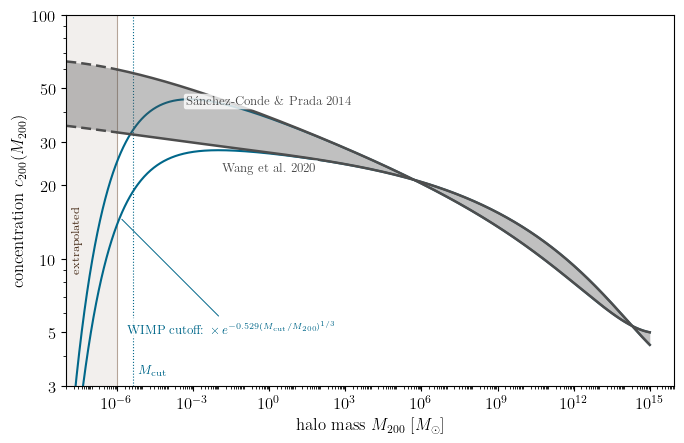

In [17]:
# --- the two concentration-mass relations, on their own axes ---
# Produces figs/concentration.pdf: the c_200(M_200) relations that set the two edges of the
# non-linear halo band of Fig. matter_power.  They agree to ~10% near 10^6 M_Solar, where
# both are anchored to simulations, and drift apart to a factor ~1.8 at the substellar
# masses that carry the small-scale power -- which is precisely the width of that band.
# Solid over 10^-6 - 10^15 M_Solar (the range the two fits quote); dashed and shaded below,
# where both polynomials are extrapolations (the SCP14 one even turns over near 10^-9).
# Gray = pure CDM (no cutoff, the null hypothesis); blue = fiducial 100 GeV WIMP, whose
# exp[-0.529 (M_cut/M)^(1/3)] factor collapses both relations below M_cut.  The blue curves
# are drawn UNDER the gray ones over the full mass range, so they show only where the
# cutoff actually bites; above it the two coincide by construction.
fig, ax = plt.subplots(1, 1, figsize=(7, 4.6))
dark_gray = (0.30, 0.30, 0.30)

vec_M_c   = np.logspace(-8, 15, 900) * M_Solar   # mass grid shared with the rho_s cell below
M_sun_c   = vec_M_c / M_Solar
M_fit_min = 1e-6                                 # [M_Solar] lower end of the quoted fit ranges
msk_fit   = M_sun_c >= M_fit_min

# axes follow vec_M_c, so changing the grid above moves the frame and the ticks with it
xlim = (M_sun_c[0], M_sun_c[-1]); ylim = (3, 1e2)
_dec = np.arange(np.ceil(np.log10(xlim[0])), np.log10(xlim[1]) + 0.5)          # decades in range
_maj = _dec[_dec % 3 == 0]                                                     # label every third
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel(r'halo mass $M_{200}~[M_\odot]$')
ax.set_ylabel(r'concentration $c_{200}(M_{200})$')
ax.set_xticks(10.0**_maj, minor=False)
ax.set_xticks(np.outer(10.0**_dec, range(1, 10)).flatten(), minor=True)
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_yticks([3, 5, 10, 20, 30, 50, 100])
ax.set_yticklabels(['3', '5', '10', '20', '30', '50', '100'])
ax.yaxis.set_minor_formatter(plt.NullFormatter())

# masses below the simulated range: everything there is polynomial extrapolation
ax.axvspan(xlim[0], M_fit_min, color=(0.36, 0.21, 0.11, 0.08), lw=0, zorder=0.5)
ax.axvline(M_fit_min, color=(0.36, 0.21, 0.11, 0.45), lw=0.8, zorder=0.6)
ax.text(xlim[0] * 10**0.4, 12, r'extrapolated', rotation=90, fontsize=8.5,
        color=(0.26, 0.15, 0.07), ha='center', va='center')

# fiducial WIMP: the same relations times the damping-cutoff suppression (drawn first)
ax.plot(M_sun_c, conc_Wang(vec_M_c),  color=colors[3], lw=1.5, zorder=2.0)
ax.plot(M_sun_c, conc_SCP14(vec_M_c), color=colors[3], lw=1.5, zorder=2.0)
ax.axvline(M_cut / M_Solar, color=colors[3], lw=0.8, ls='dotted', zorder=1.9)
ax.text(M_cut / M_Solar * 1.5, 3.3, r'$M_\mathrm{cut}$', color=colors[3],
        fontsize=9.5, ha='left', va='bottom')
_M_pt = 1.3e-6                                                                 # anchor on the blue curve
ax.annotate(r'WIMP cutoff: $\times\, e^{-0.529 (M_\mathrm{cut}/M_{200})^{1/3}}$',
            xy=(_M_pt, conc_Wang(_M_pt * M_Solar)), xytext=(3e-2, 5.2),
            color=colors[3], fontsize=9, ha='center', va='center', zorder=4,
            bbox=dict(boxstyle='round,pad=0.20', facecolor=(1, 1, 1, 0.8), edgecolor='none'),
            arrowprops=dict(arrowstyle='-', color=colors[3], lw=0.7, shrinkA=2, shrinkB=2))

# pure CDM: the band of Fig. matter_power, between the two relations
c_W = conc_Wang_nocut(vec_M_c)
c_S = conc_SCP14_nocut(vec_M_c)
ax.fill_between(M_sun_c, c_W, c_S, color=dark_gray, alpha=0.35, lw=0, zorder=2.2)
for c_ in (c_W, c_S):
    ax.plot(M_sun_c[msk_fit],  c_[msk_fit],  color=dark_gray, lw=1.8, zorder=2.4)
    ax.plot(M_sun_c[~msk_fit], c_[~msk_fit], color=dark_gray, lw=1.8, zorder=2.4, ls=(0, (4, 2)))

# in-place curve labels, on translucent white so they stay legible over the band
def _lab_c(M_lab, c_of_M, text, dy, va):
    ax.text(M_lab, c_of_M(M_lab * M_Solar) * dy, text, color=dark_gray, fontsize=9,
            ha='center', va=va, zorder=4,
            bbox=dict(boxstyle='round,pad=0.18', facecolor=(1, 1, 1, 0.8), edgecolor='none'))
_lab_c(1e0, conc_SCP14_nocut, r"S\'anchez-Conde \& Prada 2014", 1.10, 'bottom')
_lab_c(1e0, conc_Wang_nocut,  r'Wang et al.\ 2020',             0.91, 'top')

fig.tight_layout()
fig.savefig('../figs/concentration.pdf', bbox_inches='tight')

for M in np.array([1e-8, 1e-6, 1e0, 1e6, 1e12, 1e15]) * M_Solar:
    print('M = %8.0e M_sun:  c_Wang = %6.1f, c_SCP14 = %6.1f  (ratio %.2f)'
          % (M / M_Solar, conc_Wang_nocut(M), conc_SCP14_nocut(M),
             conc_SCP14_nocut(M) / conc_Wang_nocut(M)))

M =    1e-08 M_sun:  rho_s =   0.0375 (Wang),   0.1898 (SCP14) M_sun/pc^3  [ratio 5.1]  | Einasto rho_s =   0.0354
M =    1e-06 M_sun:  rho_s =   0.0319 (Wang),   0.1548 (SCP14) M_sun/pc^3  [ratio 4.9]  | Einasto rho_s =   0.0299
M =    1e+00 M_sun:  rho_s =   0.0194 (Wang),   0.0466 (SCP14) M_sun/pc^3  [ratio 2.4]  | Einasto rho_s =   0.0179
M =    1e+06 M_sun:  rho_s =   0.0094 (Wang),   0.0091 (SCP14) M_sun/pc^3  [ratio 1.0]  | Einasto rho_s =   0.0086
M =    1e+12 M_sun:  rho_s =   0.0013 (Wang),   0.0009 (SCP14) M_sun/pc^3  [ratio 0.7]  | Einasto rho_s =   0.0012


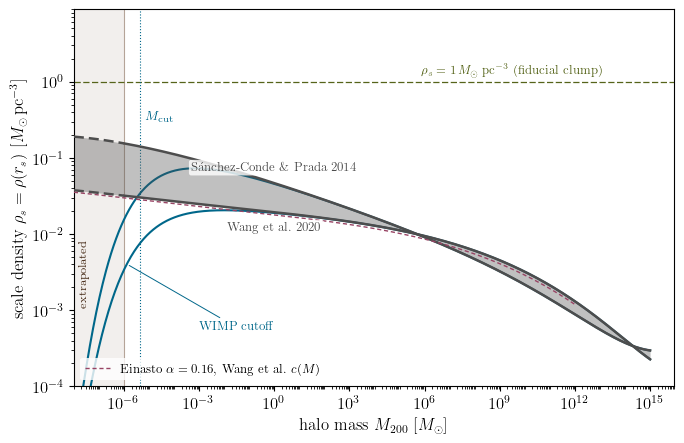

In [18]:
# --- the scale density those concentrations imply ---
# Produces figs/scale_density.pdf: the same two relations expressed as rho_s(M_200), which is
# the quantity the astrometric signal actually responds to (the y axis of Fig. SNR) and the
# reason the concentration spread matters. A halo of mass M_200 and concentration c has all
# of its structure fixed, so rho_s follows from c alone -- and because rho_s ~ c^3, the ~1.8x
# concentration gap at substellar masses becomes a factor ~5 in density.
# Convention: rho_s = rho(r_s), matching rho_s_Einasto_200 and Sec. III B of the paper; the
# standard NFW characteristic density rho_char = M_200 / (4 pi r_s^3 [ln(1+c) - c/(1+c)]) is
# 4x larger. Colors as in the cell above: gray = pure CDM, blue = WIMP damping cutoff.
def rho_s_NFW_200(M_200, conc):
    """Scale density rho_s = rho(r_s) of an NFW halo of mass M_200 with concentration conc(M_200).
    M_200 = (4 pi/3) 200 rho_crit r_200^3 gives rho_char = (200/3) rho_crit c^3/[ln(1+c) - c/(1+c)],
    and rho_NFW(r_s) = rho_char/4."""
    c = conc(M_200)
    return (50/3) * rho_crit * c**3 / (np.log(1 + c) - c/(1 + c))

fig, ax = plt.subplots(1, 1, figsize=(7, 4.6))

rho_unit = M_Solar / pc**3
xlim = (M_sun_c[0], M_sun_c[-1]); ylim = (1e-4, 3)      # same frame as the cell above
_dec = np.arange(np.ceil(np.log10(xlim[0])), np.log10(xlim[1]) + 0.5)
_maj = _dec[_dec % 3 == 0]
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel(r'halo mass $M_{200}~[M_\odot]$')
ax.set_ylabel(r'scale density $\rho_s = \rho(r_s)~[M_\odot\,\mathrm{pc^{-3}}]$')
ax.set_xticks(10.0**_maj, minor=False)
ax.set_xticks(np.outer(10.0**_dec, range(1, 10)).flatten(), minor=True)
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_yticks(np.logspace(-4, 0, 5), minor=False)
ax.set_yticks(np.outer(np.logspace(-4, 0, 5), range(1, 10)).flatten(), minor=True)
ax.yaxis.set_minor_formatter(plt.NullFormatter())

# masses below the simulated range: everything there is polynomial extrapolation
ax.axvspan(xlim[0], M_fit_min, color=(0.36, 0.21, 0.11, 0.08), lw=0, zorder=0.5)
ax.axvline(M_fit_min, color=(0.36, 0.21, 0.11, 0.45), lw=0.8, zorder=0.6)
ax.text(xlim[0] * 10**0.4, 3e-3, r'extrapolated', rotation=90, fontsize=8.5,
        color=(0.26, 0.15, 0.07), ha='center', va='center')

# fiducial clump density of Fig. SNR and of the clump overlay above: CDM halos sit one to two
# orders of magnitude below it, which is what the (M_L, rho_s) plane of Fig. SNR has to cover
ax.axhline(1.0, color=colors[0], lw=0.9, ls=(0, (5, 2)), zorder=2.0)
ax.text(3e9, 1.15, r'$\rho_s = 1\,M_\odot\,\mathrm{pc^{-3}}$ (fiducial clump)', color=colors[0],
        fontsize=9, ha='center', va='bottom', zorder=4)

# fiducial WIMP: the cutoff-suppressed concentrations, drawn under the gray (see cell above)
ax.plot(M_sun_c, rho_s_NFW_200(vec_M_c, conc_Wang)  / rho_unit, color=colors[3], lw=1.5, zorder=2.2)
ax.plot(M_sun_c, rho_s_NFW_200(vec_M_c, conc_SCP14) / rho_unit, color=colors[3], lw=1.5, zorder=2.2)
ax.axvline(M_cut / M_Solar, color=colors[3], lw=0.8, ls='dotted', zorder=2.1)
ax.text(M_cut / M_Solar * 1.5, 0.35, r'$M_\mathrm{cut}$', color=colors[3],
        fontsize=9.5, ha='left', va='center')
_M_pt = 1.3e-6                                      # same anchor on the blue curve as above
ax.annotate(r'WIMP cutoff', xy=(_M_pt, rho_s_NFW_200(_M_pt * M_Solar, conc_Wang) / rho_unit),
            xytext=(3e-2, 6e-4), color=colors[3], fontsize=9, ha='center', va='center', zorder=4,
            bbox=dict(boxstyle='round,pad=0.20', facecolor=(1, 1, 1, 0.8), edgecolor='none'),
            arrowprops=dict(arrowstyle='-', color=colors[3], lw=0.7, shrinkA=2, shrinkB=2))

# pure CDM: the band between the two relations
rho_W = rho_s_NFW_200(vec_M_c, conc_Wang_nocut)  / rho_unit
rho_S = rho_s_NFW_200(vec_M_c, conc_SCP14_nocut) / rho_unit
ax.fill_between(M_sun_c, rho_W, rho_S, color=dark_gray, alpha=0.35, lw=0, zorder=2.4)
for r_ in (rho_W, rho_S):
    ax.plot(M_sun_c[msk_fit],  r_[msk_fit],  color=dark_gray, lw=1.8, zorder=2.6)
    ax.plot(M_sun_c[~msk_fit], r_[~msk_fit], color=dark_gray, lw=1.8, zorder=2.6, ls=(0, (4, 2)))

# cross-check: the Einasto (alpha = 0.16) scale density of sensitivity_functions, built from the
# same Wang et al. concentrations -- this is the curve that carries the LambdaCDM prediction of
# Fig. SNR. It tracks the NFW lower edge to ~7%, i.e. the profile shape hardly matters here.
msk_E = M_sun_c <= 1e12                             # tabulation range of rho_s_Einasto_200
ax.plot(M_sun_c[msk_E], rho_s_Einasto_200(vec_M_c[msk_E]) / rho_unit, color=colors[4], lw=1.0,
        ls=(0, (3, 2)), zorder=3, label=r'Einasto $\alpha = 0.16$, Wang et al.\ $c(M)$')
ax.legend(loc='lower left', frameon=True, framealpha=0.8, facecolor='white',
          edgecolor='none', fontsize=9)

# in-place curve labels, as in the cell above
def _lab_r(M_lab, conc, dy, va, text):
    ax.text(M_lab, rho_s_NFW_200(M_lab * M_Solar, conc) / rho_unit * dy, text, color=dark_gray,
            fontsize=9, ha='center', va=va, zorder=4,
            bbox=dict(boxstyle='round,pad=0.18', facecolor=(1, 1, 1, 0.8), edgecolor='none'))
_lab_r(1e0, conc_SCP14_nocut, 1.35, 'bottom', r"S\'anchez-Conde \& Prada 2014")
_lab_r(1e0, conc_Wang_nocut,  0.74, 'top',    r'Wang et al.\ 2020')

fig.tight_layout()
fig.savefig('../figs/scale_density.pdf', bbox_inches='tight')

for M in np.array([1e-8, 1e-6, 1e0, 1e6, 1e12]) * M_Solar:
    print('M = %8.0e M_sun:  rho_s = %8.4f (Wang), %8.4f (SCP14) M_sun/pc^3  [ratio %.1f]'
          '  | Einasto rho_s = %8.4f' % (M / M_Solar,
          rho_s_NFW_200(M, conc_Wang_nocut) / rho_unit, rho_s_NFW_200(M, conc_SCP14_nocut) / rho_unit,
          rho_s_NFW_200(M, conc_SCP14_nocut) / rho_s_NFW_200(M, conc_Wang_nocut),
          rho_s_Einasto_200(M) / rho_unit))

In [19]:
# --- prompt cusps (Delos & White 2023): rho = A r^{-3/2} between r_core and r_cusp ---
# Each density peak collapses promptly into a r^{-3/2} cusp; A and r_cusp follow from the peak.
z5_cusp    = 31.0       # redshift by which 5% of initial peaks have collapsed (fiducial WIMP)
f_surv     = 0.5        # fraction of cusps surviving hierarchical assembly
ratio_cusp = 500.0      # r_cusp / r_core for WIMP prompt cusps
r_cusp_med = 5e-3 * pc  # characteristic outer cusp radius (annihilation/power-weighted)

def _cusp_FT2(k, r_cusp, r_core):
    """ |rho_tilde(k)|^2 k^3 / (8 pi^3 A^2) for a truncated, cored r^{-3/2} cusp.
        -> 1 on the cusp plateau (1/r_cusp << k << 1/r_core); ~ (k r_cusp)^3 below; -> 0 above. """
    Sc, _ = sp.special.fresnel(np.sqrt(2 * k * r_cusp / np.pi))
    So, _ = sp.special.fresnel(np.sqrt(2 * k * r_core / np.pi))
    I_cusp = np.sqrt(2 * np.pi / k) * (Sc - So)                                    # int_{r_core}^{r_cusp} r^{-1/2} sin(kr) dr
    I_core = r_core**-1.5 * (np.sin(k * r_core) - k * r_core * np.cos(k * r_core)) / k**2
    return ((4 * np.pi / k) * (I_core + I_cusp))**2 * k**3 / (8 * np.pi**3)

def Delta2_cusp(k, z5=z5_cusp, ratio=ratio_cusp, r_cusp=r_cusp_med):
    """Dimensionless matter power spectrum contributed by prompt cusps.
       Plateau amplitude anchored to Delos & White 2023, Eq. (2.8): the cusps' mean
       squared density per unit mass is 160 f_surv (1+z5)^3 times the cosmic mean.
       Only the plateau's LEFT EDGE, k ~ 1/r_cusp, moves with the damping
       cutoff; the amplitude above is nearly cutoff-independent."""
    k = np.atleast_1d(k).astype(float)
    plateau = 160 * f_surv * (1 + z5)**3 / (0.531 + np.log(ratio))
    lnr = np.log(r_cusp) + np.linspace(-1.5, 1.5, 21) * 0.6                        # spread in cusp size
    w = np.exp(-((lnr - np.log(r_cusp)) / 0.6)**2 / 2); w /= w.sum()
    shape = np.zeros_like(k)
    for lr, wi in zip(lnr, w):
        shape += wi * _cusp_FT2(k, np.exp(lr), np.exp(lr) / ratio)
    return plateau * shape

# A WARMER relic pushes the cutoff up, M_cut ~ T_kd^-3, and with it the cusp size,
# r_cusp ~ M_cut^(1/3) ~ T_kd^-1 -- sliding the whole plateau LEFT at fixed height, onto
# the sensitivity minimum. The LINE-OF-SIGHT cusps never reach SNR = 1 over this sweep:
# los_full_spectrum_snr.py peaks at ~0.46 (stochastic, EPIC on B1422) near T_kd ~ 4 MeV
# and turns over. The detectable case is the LENS-BOUND population of cusp_snr.py:
T_kd_det   = 6.0                                    # MeV: the lens-bound detection
                                                    # threshold of Sec. IV C (cusp_snr.py)
r_cusp_det = r_cusp_med * (T_kd_det / 30.)**-1

print('prompt-cusp plateau:  Delta^2 = %.2g' % (160 * f_surv * (1 + z5_cusp)**3 / (0.531 + np.log(ratio_cusp))))
print('r_cusp = %.2e pc (T_kd = 30 MeV) -> %.2e pc (T_kd = %.0f MeV)'
      % (r_cusp_med / pc, r_cusp_det / pc, T_kd_det))

prompt-cusp plateau:  Delta^2 = 3.9e+05
r_cusp = 5.00e-03 pc (T_kd = 30 MeV) -> 2.50e-02 pc (T_kd = 6 MeV)


In [20]:
# evaluate the linear and non-linear estimates on the extended wavenumber grid
k_nat_ext    = kk_ext * Mpc**-1
D2_lin_cut   = Delta2_lin(k_nat_ext, cutoff=True)         # linear, with WIMP damping cutoff
# pure CDM (null hypothesis): no cutoff anywhere -- ever smaller halos keep contributing
D2_nl_CDM_lo = Delta2_PS(k_nat_ext, conc=conc_Wang_nocut,  cutoff=False)
D2_nl_CDM_hi = Delta2_PS(k_nat_ext, conc=conc_SCP14_nocut, cutoff=False)
# fiducial WIMP: damping cutoff (mass function + concentrations) and prompt cusps
D2_nl_PS_lo  = Delta2_PS(k_nat_ext, conc=conc_Wang)       # halos, pessimistic concentrations (Wang et al. 2020)
D2_nl_PS_hi  = Delta2_PS(k_nat_ext, conc=conc_SCP14)      # halos, optimistic concentrations (Sanchez-Conde & Prada 2014)
D2_nl_cusp   = Delta2_cusp(k_nat_ext)                     # prompt cusps
D2_nl_cusp_d = Delta2_cusp(k_nat_ext, r_cusp=r_cusp_det)  # ditto, for the detectable T_kd
D2_nl_tot_lo = D2_nl_PS_lo + D2_nl_cusp                   # total WIMP estimate (band edges)
D2_nl_tot_hi = D2_nl_PS_hi + D2_nl_cusp

# --- monochromatic clump population, the read-across to the (M_L, rho_s) plane of Fig. SNR ---
# Clumps of a single mass M_L and scale density rho_L, in the profile convention of Sec. III B
# (rho ~ exp[-r^2/2 r_L^2]/r with rho_L = rho(r_L), so M_L = 4 pi sqrt(e) rho_L r_L^3 and the
# form factor is Gaussian). Their Poisson (shot-noise) contribution to the spectrum is
#     Delta^2(k) = k^3 f_sub M_L |u(k)|^2 / (2 pi^2 rho_m,0),   |u(k)|^2 = exp[-(k r_L)^2],
# the same convention as los_vs_lens_decomposition.py.  It peaks at k = sqrt(3/2)/r_L with a
# height Delta^2_peak = 0.430 f_sub rho_L/rho_m,0 that depends only on f_sub and rho_L, not on
# M_L -- so the three curves drawn below share a common peak and differ only in k.
#
# TWO conventions, both of which used to be wrong here (and in the caption of the figure):
#  - rho_L is the PHYSICAL scale density at the lens, the y axis of Fig. SNR, so the comoving
#    clump radius is r_L (1 + z_L) -- the same conversion as _rL_chk further below.
#  - the f_sub passed in is the PLOTTED, cosmic-mean-equivalent mass fraction, NOT the fraction
#    of an image's convergence. The two are related through ell_sub; the curves are therefore
#    evaluated in the lens-bound cell below, where ell_sub exists.
def r_L_of_M(M_L, rho_L):
    return (M_L / (4 * np.pi * np.sqrt(np.e) * rho_L))**(1/3)

def Delta2_clump(k, M_L, rho_L=1 * M_Solar / pc**3, f_sub=0.1):
    r_L = r_L_of_M(M_L, rho_L) * (1 + pB.z_lens)          # comoving, matching the comoving k
    return k**3 * f_sub * M_L * np.exp(-(k * r_L)**2) / (2 * np.pi**2 * rho_M_0)


In [21]:
# ---------------------------------------------------------------------------
# Lens-bound substructure of B1422+231 -- the SECOND population, and the one for which the
# kernel is exact: both off-plane corrections (notes/off_plane_los_kernel.md) are unity at
# chi = chi_L, so nothing here rests on the multi-plane approximation.
#
# The slab is modeled as a comoving path ell_sub of mean-density universe placed at the lens
# plane, chosen to carry the substructure column of image B,
#     Sigma_sub = f_sub kappa^B Sigma_cr / (1 + z_L)^2   (comoving),
# spread over a Sheth-Tormen mass function on M_min_sub < M < M_max_sub. The predicted spectrum of
# that population, Delta2_PS_sub, is the same one-halo construction as the gray field-halo
# band but with the Moline+2017 SUBhalo concentrations of Fig. SNR, and is plotted RAW: it is
# a cosmic-mean-equivalent Delta^2 like every other prediction on these axes. All the
# lens-specific normalization (f_sub, kappa^B, M_max) therefore sits in the sensitivity
# curves, which are the line-of-sight ones divided by the slab/sightline signal ratio ~20.
# ---------------------------------------------------------------------------
x_sub_lens   = pB.x_sub_fid          # 0.03, the LOS-weighted host-centric distance of A,B,C
f_sub_lens   = 0.5                   # substructure fraction of the image convergence
i_img_sub    = 1                     # image B -- the image sys_gal is built on
M_max_sub    = 1e9 * M_Solar         # heaviest surviving subhalo
M_min_sub    = np.exp(_lnM_1h[0])    # lightest: this band is a PURE-CDM prediction, so like the
                                     # gray one it carries no damping cutoff -- the floor is just
                                     # the tabulation floor, 1e-13 M_Solar. That is low enough
                                     # that neither band rolls over inside the figure: the Moline
                                     # r_s there corresponds to k ~ 1e11 h/Mpc, 10x past the right
                                     # edge (Wang, for the gray band, 5.5e10). Do NOT push it
                                     # lower -- the Moline c(M) fit peaks near 1e-6 M_Solar and
                                     # goes NEGATIVE below 2.5e-17, and SCP14 collapses to c = 4
                                     # by 1e-16, so a deeper floor manufactures a worse artifact
                                     # than it removes. A physical cutoff instead RAISES the
                                     # floor: at the fiducial relic's M_cut = 4.5e-6 M_Solar the
                                     # same column sits in fewer, more useful halos and the SNR
                                     # rises ~10% (see the M_min table in the last section).
kappa_img    = np.load('macro_lens_results.npz')['kappa_fit'][i_img_sub]
a_lens       = 1 / (1 + pB.z_lens)
_dlnM_1h     = _lnM_1h[1] - _lnM_1h[0]
col_sub      = (0.42, 0.28, 0.68)    # violet: not used by any other element of this figure

def conc_Moline_sub(M_200, x_sub=None):
    """Median SUBhalo concentration c_200(M_200, x_sub) of Moline+2017 Eq. (7), clipped like
    conc_Wang/conc_SCP14 above. This is the relation behind the dashed line of Fig. SNR."""
    return np.clip(c_200_Moline(M_200, x_sub if x_sub is not None else x_sub_lens), 2, 200)

def f_ST_range(M_min=None, M_max=None):
    """Fraction of the cosmic matter density that the tabulated Sheth-Tormen mass function
    puts in halos of mass M_min < M < M_max (pure CDM, no cutoff) -- exactly the population
    that Delta2_PS_sub sums, and hence the column the slab has to carry.

    The model-independent content is the fraction per e-fold, df/dlnM = (M/rho_m,0) dn/dlnM,
    which ST makes a slowly RISING function of mass: 0.0012 per e-fold at 1e-6 M_Solar,
    0.0028 at 1 M_Solar, 0.017 near 1e9 M_Solar. The cumulative is therefore dominated by
    the top decade or two and is insensitive to the floor -- f(-> 1e9 M_Solar) = 0.188 from
    1e-6 M_Solar, 0.210 from 1e-13 M_Solar (the floor adopted here), 0.225 from 1e-16 M_Solar
    -- while a decade in M_max moves it by +-25%."""
    M_min = M_min_sub if M_min is None else M_min
    M_max = M_max_sub if M_max is None else M_max
    return sum(dn_dlnM(np.exp(l), False) * np.exp(l)
               for l in _lnM_1h if M_min <= np.exp(l) <= M_max) * _dlnM_1h / rho_M_0

def Delta2_PS_sub(k, x_sub=None, M_max=None, M_min=None):
    """One-halo Delta^2 of the subhalo population at the COSMIC MEAN density: the same
    Sheth-Tormen mass function as the gray band, restricted to M_min < M < M_max, with NFW
    profiles carrying the Moline+2017 subhalo concentrations at host distance x_sub.

    The SAME mass range must be used here and in f_ST_range: the slab carries the column of
    this population, so numerator and denominator have to count the same halos."""
    M_max = M_max_sub if M_max is None else M_max
    M_min = M_min_sub if M_min is None else M_min
    k = np.atleast_1d(k).astype(float)
    integral = np.zeros_like(k)
    _c = lambda MM: conc_Moline_sub(MM, x_sub)
    for lnM in _lnM_1h:
        M = np.exp(lnM)
        if not (M_min <= M <= M_max):
            continue
        integral += dn_dlnM(M, False) * M**2 * u_NFW(k, M, _c)**2 * _dlnM_1h
    return k**3 / (2 * np.pi**2) * integral / rho_M_0**2

Sigma_sub_com = f_sub_lens * kappa_img * Sigma_crit_gal * a_lens**2
f_sub_ST = f_ST_range()
ell_sub = Sigma_sub_com / (f_sub_ST * rho_M_0)
print('kappa^%s = %.4f  ->  Sigma_sub = %.0f M_Solar/pc^2 comoving, ell_sub = %.0f Mpc'
      % ('ABCD'[i_img_sub], kappa_img, Sigma_sub_com/(M_Solar/pc**2), ell_sub/Mpc))
print('f(%.0e - %.0e M_Solar) = %.4f  |  df/dlnM = %.5f per e-fold at %.0e, %.5f at %.0e'
      % (M_min_sub/M_Solar, M_max_sub/M_Solar, f_sub_ST,
         dn_dlnM(M_min_sub, False)*M_min_sub/rho_M_0, M_min_sub/M_Solar,
         dn_dlnM(M_max_sub, False)*M_max_sub/rho_M_0, M_max_sub/M_Solar))

# the lens-bound "system": same instrument, same B^I and mu_tilde, thin slab instead of a
# sightline. Kept out of `systems` so the line-of-sight loops above are untouched.
sys_lens = dict(sys_gal, label='B1422+231 lens-bound subhalos (0.1 muas)',
                ls=(0, (1, 1.4)), slab=(pB.D_lens, a_lens, ell_sub))

_C_noise_lens = C_inst(omega=1.001*omega_min, tau=tau, N_obs=N_obs,
                       sigma_delta_theta=sys_lens['sigma_delta_theta'])
_s2_noise_lens = 720 * sys_lens['sigma_delta_theta']**2 / (tau**4 * N_obs)
def _threshold(signal, noise):          # nan where no plane can source that mode at all
    signal = np.asarray(signal, float)
    return np.where(signal > 0, noise/np.where(signal > 0, signal, 1), np.nan)

sys_lens['Delta2_stoch'] = _threshold(
    [C_pq(omega=omega_min, sys=sys_lens, k=k, Delta2=1) for k in vec_k_stoch], _C_noise_lens)
sys_lens['Delta2_acc'] = _threshold(
    [sigma2_acc_signal(tau=tau, sys=sys_lens, k=k, Delta2=1) for k in vec_k_acc], _s2_noise_lens)

# the prediction: raw (cosmic-mean-equivalent) spectrum of that population, x_sub band
D2_sub_band = {x: Delta2_PS_sub(k_nat_ext, x) for x in (0.1, x_sub_lens, 0.01)}

_i_st = int(np.nanargmin(sys_lens['Delta2_stoch'])); _i_ac = int(np.nanargmin(sys_lens['Delta2_acc']))
_j8 = int(np.argmin(np.abs(k_h_ext - 1e8)))
print('%-36s stoch: %.3g at k = %.3g h/Mpc | acc: %.3g at k = %.3g h/Mpc'
      % (sys_lens['label'], sys_lens['Delta2_stoch'][_i_st], vec_k_stoch[_i_st]/(cosmo.h*Mpc**-1),
         sys_lens['Delta2_acc'][_i_ac], vec_k_acc[_i_ac]/(cosmo.h*Mpc**-1)))
print('  slab/sightline gain: stoch x%.1f, acc x%.1f  |  predicted Delta^2 at k = 1e8 h/Mpc:'
      ' %.3g (subhalo c_200) vs %.3g - %.3g (field halos)'
      % (sys_gal['Delta2_stoch'][_i_st]/sys_lens['Delta2_stoch'][_i_st],
         sys_gal['Delta2_acc'][_i_ac]/sys_lens['Delta2_acc'][_i_ac],
         D2_sub_band[x_sub_lens][_j8], D2_nl_CDM_lo[_j8], D2_nl_CDM_hi[_j8]))

# --- the monochromatic clump curves of Fig. SNR, placed on these axes ---------------------
# Fig. SNR's fiducial is f_sub_clump_lens of image B's convergence in clumps of ONE mass at
# rho_L = 1 M_Solar/pc^3 (physical). To be legible against the lens-bound thresholds it has to
# be drawn in the same cosmic-mean-equivalent normalization as Delta2_PS_sub, i.e. with the
# mass fraction that puts its column on the slab's equivalent path ell_sub:
#     f_sub_clump = Sigma_clump^com / (rho_m,0 ell_sub) = f_ST f_clump / f_sub_lens.
# The height of these curves above the dotted thresholds is then the variance SNR of Fig. SNR,
# and that ratio is independent of the assumed mass range, since f_ST cancels between them.
f_sub_clump_lens = 0.5                    # fraction of kappa^B in clumps -- the Fig. SNR fiducial
rho_L_clump   = 1.0 * M_Solar / pc**3     # PHYSICAL scale density at the lens (y axis of Fig. SNR)
f_sub_clump   = f_sub_clump_lens * kappa_img * Sigma_crit_gal * a_lens**2 / (rho_M_0 * ell_sub)
M_L_clumps    = np.array([1e0, 1e-3, 1e-6]) * M_Solar
lab_M_clumps  = [r'$1\,M_\odot$', r'$10^{-3}\,M_\odot$', r'$10^{-6}\,M_\odot$']
D2_clumps     = [Delta2_clump(k_nat_ext, M, rho_L_clump, f_sub_clump) for M in M_L_clumps]
print('clumps: f_sub = %.2f of kappa^%s  ->  plotted cosmic-mean-equivalent fraction %.4f'
      % (f_sub_clump_lens, 'ABCD'[i_img_sub], f_sub_clump))
for M, D2 in zip(M_L_clumps, D2_clumps):
    i = int(np.argmax(D2))
    print('  M_L = %8.0e M_sun:  r_L = %8.3g pc,  peak Delta^2 = %.3g at k = %.3g h/Mpc'
          % (M / M_Solar, r_L_of_M(M, rho_L_clump) / pc, D2[i], k_h_ext[i]))
print('  peak / lens-bound acceleration threshold = %.1f   [cf. peak acc SNR ~ 23 in Fig. SNR]'
      % (max(D2.max() for D2 in D2_clumps) / sys_lens['Delta2_acc'][_i_ac]))


kappa^B = 0.4628  ->  Sigma_sub = 267 M_Solar/pc^2 comoving, ell_sub = 31076 Mpc
f(1e-13 - 1e+09 M_Solar) = 0.2099  |  df/dlnM = 0.00100 per e-fold at 1e-13, 0.01970 at 1e+09


B1422+231 lens-bound subhalos (0.1 muas) stoch: 3.14e+04 at k = 1.14e+08 h/Mpc | acc: 3.91e+04 at k = 8.64e+07 h/Mpc
  slab/sightline gain: stoch x52.2, acc x20.5  |  predicted Delta^2 at k = 1e8 h/Mpc: 4.21e+04 (subhalo c_200) vs 1.83e+03 - 5.32e+03 (field halos)
clumps: f_sub = 0.50 of kappa^B  ->  plotted cosmic-mean-equivalent fraction 0.2099
  M_L =    1e+00 M_sun:  r_L =    0.364 pc,  peak Delta^2 = 9.17e+05 at k = 3.7e+06 h/Mpc
  M_L =    1e-03 M_sun:  r_L =   0.0364 pc,  peak Delta^2 = 9.16e+05 at k = 3.72e+07 h/Mpc
  M_L =    1e-06 M_sun:  r_L =  0.00364 pc,  peak Delta^2 = 9.17e+05 at k = 3.69e+08 h/Mpc
  peak / lens-bound acceleration threshold = 23.5   [cf. peak acc SNR ~ 23 in Fig. SNR]


# Plot

In [22]:
colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

B1422+231 (galaxy) + EPIC, 0.1 muas  stoch: 9.06e+05 at k = 1.45e+08 h/Mpc | acc: 8.03e+05 at k = 8.64e+07 h/Mpc
SDSS J1029+2623 (cluster), 1 muas    stoch: 1.19e+07 at k = 9.88e+07 h/Mpc | acc: 1.1e+07 at k = 6.98e+07 h/Mpc


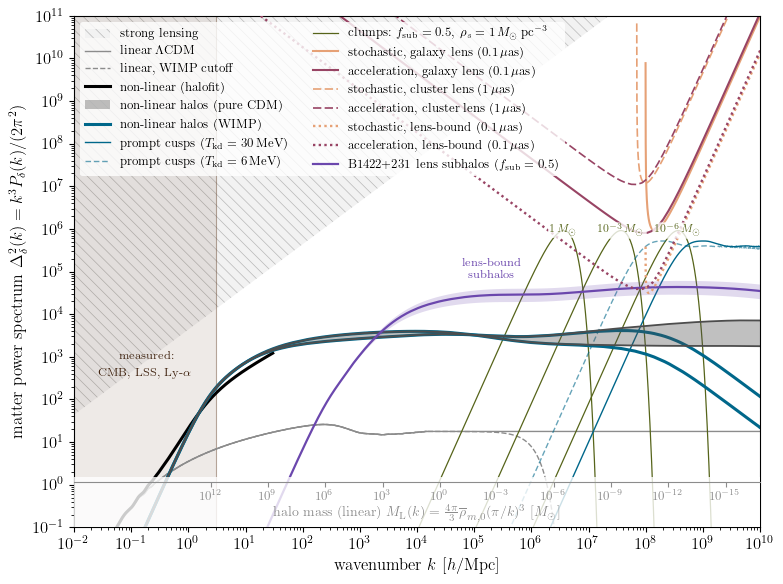

In [23]:
fig,ax = plt.subplots(1,1,figsize=(8,6))

xlim = (1e-2,1e10); ax.set_xlim(xlim);
ylim = (1e-1,1e11); ax.set_ylim(ylim);
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'wavenumber $k~[h/\mathrm{Mpc}]$');
ax.set_ylabel(r'matter power spectrum $\Delta^2_\delta(k) = k^3 P_\delta(k) / (2 \pi^2)$');
ax.set_xticks(np.logspace(np.log10(xlim[0]),np.log10(xlim[1]),1+int(np.log10(xlim[1]/xlim[0]))),minor=False);
ax.set_xticks(np.outer(np.logspace(np.log10(xlim[0]),np.log10(xlim[1])-1,int(np.log10(xlim[1]/xlim[0]))),range(1,10)).flatten(),minor=True);
ax.set_yticks(np.logspace(np.log10(ylim[0]),np.log10(ylim[1]),1+int(np.log10(ylim[1]/ylim[0]))),minor=False);
ax.set_yticks(np.outer(np.logspace(np.log10(ylim[0]),np.log10(ylim[1])-1,int(np.log10(ylim[1]/ylim[0]))),range(1,10)).flatten(),minor=True);

# strong-lensing regime: one e-fold of power at k drives the rms convergence to the source
# past unity (see the strong-lensing cell). Drawn for the deeper B1422+231 sightline; the
# shallower cluster sightline's boundary lies a factor ~3 higher.
# NB: opaque grays, NOT translucent RGBA.  The PDF backend drops the alpha channel of both
# the facecolor and the hatch color and applies a single global alpha to the tile, so a
# (0,0,0,0.05) face with a (0,0,0,0.22) hatch is written as black-on-black and the hatching
# vanishes from the vector output (it still looks right in the inline PNG, which honors the
# two alphas separately).  The grays below are the on-white equivalents.
plt.rcParams['hatch.linewidth'] = 0.5
ax.fill_between(k_h_ext, Delta2_strong_lens(kk_ext * Mpc**-1, sys_gal), 1e30, facecolor='0.95',
                edgecolor='0.72', hatch='\\\\\\', lw=0, label=r'strong lensing')

# wavenumbers already probed at (linear) LambdaCDM-level amplitudes: CMB, large-scale
# structure, Lyman-alpha forest reach k ~ 3 h/Mpc; everything to the right is terra incognita
brown = (0.36,0.21,0.11)
ax.axvspan(xlim[0], 3, color=brown + (0.10,), lw=0)
ax.axvline(3, color=brown + (0.45,), lw=0.8, ls='solid')
ax.text(np.sqrt(xlim[0]*3), 3e2, r'measured:\\CMB, LSS, Ly-$\alpha$',
        fontsize=8.5, color=(0.26,0.15,0.07), ha='center', va='bottom')

# linear matter power spectrum (gray -- see the floating gray mass axis below)
ax.plot(k_h,     D2_lin,     color='0.55', lw=1, ls='solid')
ax.plot(k_h_ext, D2_lin_ext, color='0.55', lw=1, ls='solid',  label=r'linear $\Lambda$CDM')
ax.plot(k_h_ext, D2_lin_cut, color='0.55', lw=1, ls='dashed', label=r'linear, WIMP cutoff')

# non-linear matter power spectrum
# the halo (Press-Schechter) prediction is a band spanning the concentration-mass relations
# of Wang et al. 2020 (lower edge) and Sanchez-Conde & Prada 2014 (upper edge)
ax.plot(k_h_ext[k_h_ext < 30], D2_nl_ext[k_h_ext < 30], color='k',         lw=2.2, label=r'non-linear (halofit)')
# fiducial WIMP: damping cutoff (thick blue, band edges) + prompt cusps (thin blue)
dark_gray = (0.30,0.30,0.30)
ax.fill_between([], [], [], color=dark_gray, alpha=0.35, lw=0,   # legend proxy (drawn below)
                label=r'non-linear halos (pure CDM)')
ax.plot(k_h_ext, D2_nl_PS_lo, color=colors[3],   lw=2.2, zorder=2.2, label=r'non-linear halos (WIMP)')
ax.plot(k_h_ext, D2_nl_PS_hi, color=colors[3],   lw=2.2, zorder=2.2)
ax.plot(k_h_ext, D2_nl_cusp,  color=colors[3],   lw=1,   zorder=2.2,
        label=r'prompt cusps ($T_\mathrm{kd} = 30\,\mathrm{MeV}$)')
# same plateau, same height, slid left by 30/T_kd: a warmer relic makes bigger cusps
ax.plot(k_h_ext, D2_nl_cusp_d, color=colors[3],   lw=1,   zorder=2.2, ls=(0,(4,2)), alpha=0.6,
        label=r'prompt cusps ($T_\mathrm{kd} = %.0f\,\mathrm{MeV}$)' % T_kd_det)
# null hypothesis: purely cold DM, no cutoff -- the one-halo band continues to arbitrarily
# high k.  Drawn last (over the blue) because the WIMP halos coincide with it below the
# damping cutoff, where the gray band would otherwise be completely hidden.
ax.fill_between(k_h_ext, D2_nl_CDM_lo, D2_nl_CDM_hi, color=dark_gray, alpha=0.35, lw=0, zorder=2.4)
ax.plot(k_h_ext, D2_nl_CDM_lo, color=dark_gray,  lw=1.3, zorder=2.4)
ax.plot(k_h_ext, D2_nl_CDM_hi, color=dark_gray,  lw=1.3, zorder=2.4)

# lens-bound subhalos of B1422+231: the same Sheth-Tormen hierarchy as the gray band, with
# the Moline+2017 SUBhalo concentrations of Fig. SNR (band: x_sub = 0.1 to 0.01). Plotted raw,
# i.e. as a cosmic-mean-equivalent Delta^2 like every other prediction here; what the lens
# adds -- its substructure column -- is carried by the dotted sensitivity curves below.
ax.fill_between(k_h_ext, D2_sub_band[0.1], D2_sub_band[0.01], color=col_sub, alpha=0.20,
                lw=0, zorder=3.0)
ax.plot(k_h_ext, D2_sub_band[x_sub_lens], color=col_sub, lw=1.6, zorder=3.2)

# monochromatic clump population: a fraction f_sub = 0.1 of the cosmic mean matter density
# in clumps of one mass M_L and scale density rho_L = 1 M_Solar/pc^3.  The peak height is set
# by f_sub * rho_L alone, so the three masses only shift the curve in k -- a direct
# read-across to the (M_L, rho_s) axes of Fig. SNR.
for M, D2, lab in zip(M_L_clumps, D2_clumps, lab_M_clumps):
    ax.plot(k_h_ext, D2, color=colors[0], lw=0.9)
    i_pk = int(np.argmax(D2))   # label centered on the peak, on a translucent white patch so
    ax.text(k_h_ext[i_pk], D2[i_pk], lab, color=colors[0], fontsize=8, zorder=4.6,
            ha='center', va='center',   # that it stays legible over the curve it belongs to
            bbox=dict(boxstyle='round,pad=0.20', facecolor=(1,1,1,0.8), edgecolor='none'))
ax.plot([], [], color=colors[0], lw=0.9,
        label=r'clumps: $f_\mathrm{sub} = 0.5$, $\rho_s = 1\,M_\odot\,\mathrm{pc^{-3}}$')

# Projected per-mode sensitivity: the minimum Delta^2 per e-fold detectable at wavenumber k
# for a population spread along the line of sight at the mean cosmological density. Both
# benchmark configurations, both instrument-limited:
#   solid  -- galaxy lens B1422+231 (B ~ 10.2, bulk |v_L| ~ 865 km/s) with EPIC, 0.1 muas
#   dashed -- cluster lens SDSS J1029+2623 (B ~ 22.6, eff. |v_L| ~ 552 km/s) at 1 muas
# color encodes the channel: stochastic (orange) and acceleration (maroon).
for s in systems:
    msk_st = s['Delta2_stoch'] > 0
    msk_ac = s['Delta2_acc']   > 0
    lw = 1.5 if s['ls'] == 'solid' else 1.2
    ax.plot(vec_k_stoch[msk_st]/(cosmo.h*Mpc**-1), s['Delta2_stoch'][msk_st],
            color=colors[2], lw=lw, ls=s['ls'])
    ax.plot(vec_k_acc[msk_ac]/(cosmo.h*Mpc**-1),   s['Delta2_acc'][msk_ac],
            color=colors[4], lw=lw, ls=s['ls'])

# The same two channels for the LENS-BOUND population of the same galaxy lens (dotted): the
# substructure column f_sub kappa^B Sigma_cr at chi_L, in place of the mean-density sightline.
# It buys a factor ~20 in Delta^2, and needs no multi-plane approximation.
for _key, _col in (('Delta2_stoch', colors[2]), ('Delta2_acc', colors[4])):
    _kk = vec_k_stoch if _key == 'Delta2_stoch' else vec_k_acc
    _m  = np.isfinite(sys_lens[_key]) & (sys_lens[_key] > 0)
    ax.plot(_kk[_m]/(cosmo.h*Mpc**-1), sys_lens[_key][_m], color=_col, lw=1.7,
            ls=sys_lens['ls'], zorder=3.4)

# legend proxies: every sensitivity key carries both its channel color and its system
# line style, so no legend entry reuses the grays of the linear-spectrum curves
ax.plot([], [], color=colors[2], lw=1.5, ls='solid',
        label=r'stochastic, galaxy lens ($0.1\,\mathrm{\mu as}$)')
ax.plot([], [], color=colors[4], lw=1.5, ls='solid',
        label=r'acceleration, galaxy lens ($0.1\,\mathrm{\mu as}$)')
ax.plot([], [], color=colors[2], lw=1.2, ls=(0,(5,2)),
        label=r'stochastic, cluster lens ($1\,\mathrm{\mu as}$)')
ax.plot([], [], color=colors[4], lw=1.2, ls=(0,(5,2)),
        label=r'acceleration, cluster lens ($1\,\mathrm{\mu as}$)')
ax.plot([], [], color=colors[2], lw=1.7, ls=sys_lens['ls'],
        label=r'stochastic, lens-bound ($0.1\,\mathrm{\mu as}$)')
ax.plot([], [], color=colors[4], lw=1.7, ls=sys_lens['ls'],
        label=r'acceleration, lens-bound ($0.1\,\mathrm{\mu as}$)')
ax.plot([], [], color=col_sub, lw=1.6,
        label=r'B1422+231 lens subhalos ($f_\mathrm{sub} = %.1f$)' % f_sub_lens)

# in-plot label for the lens-bound prediction, on the same translucent white as the clumps
_i_lab = int(np.argmin(np.abs(k_h_ext - 2e5)))
ax.text(k_h_ext[_i_lab], D2_sub_band[x_sub_lens][_i_lab]*2.2, 'lens-bound\nsubhalos',
        color=col_sub, fontsize=8.5, zorder=4.6, ha='center', va='bottom', linespacing=1.15,
        bbox=dict(boxstyle='round,pad=0.20', facecolor=(1,1,1,0.8), edgecolor='none'))

# floating gray axis: halo mass of the LINEAR (Lagrangian) perturbation of wavenumber k,
# M(k) = (4 pi / 3) rho_m (pi/k)^3. Drawn in gray and floated near the bottom to tie it to
# the gray linear curves -- this is the linear-k -> mass map, NOT the collapsed nonlinear
# scale ~1/r_L (about two decades higher) at which a halo actually feeds the power spectrum.
grey    = '0.55'
_k_unit = cosmo.h * Mpc**-1                                   # 1 h/Mpc in natural units
def _k2M(k_h):                                                # k [h/Mpc] -> M [M_sun]
    k = np.asarray(k_h, float) * _k_unit
    return (4*np.pi/3) * rho_M_0 * (np.pi / k)**3 / M_Solar
def _M2k(M):                                                  # M [M_sun] -> k [h/Mpc]
    M = np.asarray(M, float) * M_Solar
    with np.errstate(divide='ignore', invalid='ignore'):     # M -> 0 maps to k -> inf
        return np.pi / (3*M / (4*np.pi*rho_M_0))**(1/3) / _k_unit
M_exps = np.arange(12, -18, -3)
_y_secax = 0.11                                               # provisional height, lowered below
secax  = ax.secondary_xaxis(_y_secax, functions=(_k2M, _M2k))
secax.set_xticks([10.0**e for e in M_exps])
secax.set_xticklabels([r'$10^{%d}$' % e for e in M_exps])
secax.minorticks_off()
secax.set_xlabel(r'halo mass (linear) $M_\mathrm{L}(k) = \frac{4\pi}{3}\overline{\rho}_{m,0} (\pi/k)^3~[M_\odot]$',
                 fontsize=10, color=grey, labelpad=2)
secax.tick_params(colors=grey, labelsize=9)
for _sp in secax.spines.values():
    _sp.set_color(grey)

leg = ax.legend(loc='upper left', frameon=True, framealpha=0.8, facecolor='white',
                edgecolor='none', fontsize=9, ncol=2)
leg.set_zorder(6)
fig.tight_layout()

# white backdrop behind the floating mass axis, drawn in front of the curves, so its gray
# ticks and label stay legible where the steep clump and cusp curves cross them.  The axis
# is first dropped until the bottom edge of that backdrop rests on the frame.
_pad = 0.010
fig.canvas.draw()
_bb  = secax.get_tightbbox().transformed(ax.transAxes.inverted())
secax.set_location(max(_y_secax - (_bb.y0 - _pad), 0))
fig.canvas.draw()
_bb  = secax.get_tightbbox().transformed(ax.transAxes.inverted())
ax.add_patch(plt.Rectangle((_bb.x0 - _pad, _bb.y0 - _pad), _bb.width + 2*_pad, _bb.height + 2*_pad,
                           transform=ax.transAxes, facecolor=(1,1,1,0.8), edgecolor='none',
                           zorder=4.5))
secax.set_zorder(5)
fig.savefig('../figs/matter_power.pdf', bbox_inches='tight')

for s in systems:
    i_st = int(np.nanargmin(s['Delta2_stoch']))
    i_ac = int(np.argmin(np.where(s['Delta2_acc'] > 0, s['Delta2_acc'], np.inf)))
    print('%-36s stoch: %.3g at k = %.3g h/Mpc | acc: %.3g at k = %.3g h/Mpc'
          % (s['label'], s['Delta2_stoch'][i_st], vec_k_stoch[i_st]/(cosmo.h*Mpc**-1),
             s['Delta2_acc'][i_ac], vec_k_acc[i_ac]/(cosmo.h*Mpc**-1)))

# Lens-bound subhalos of B1422+231  →  `figs/matter_power_sub.pdf`

Everything above counts **field** halos at the cosmic mean density. This section adds the
population *bound to the lens galaxy itself* and produces a variant figure,
`figs/matter_power_sub.pdf`, carrying it alongside the field-halo band. The population is
the same one the paper plots: `figs/matter_power.pdf` already carries the lens-bound
sensitivity curves and the violet prediction band. What is provisional here is only the
*presentation* -- this variant rescales the prediction to a line-of-sight-equivalent
$\Delta^2$ rather than leaving the normalization in the sensitivity curves -- which is
why no figure in the paper uses it.

**Population.** The same Sheth--Tormen mass function `dn_dlnM` that builds the gray band
(pure CDM, no cutoff), with NFW profiles carrying the *subhalo* concentrations of
Moliné+2017 at $x_\mathrm{sub} = 0.03$ --- i.e. exactly the $\rho_s(M_s)$ relation of the
dashed line of `figs/SNR.pdf` (`c_200_Moline` in `sensitivity_functions.py`). Subhalos are
several times more concentrated than field halos of the same mass, which raises the
one-halo amplitude by more than an order of magnitude on its own. Like the Wang+2020 and
Sánchez-Conde & Prada 2014 relations behind the gray band, the fit is calibrated only down
to $\sim 10^{-6}\,M_\odot$ and is extrapolated below that; the right-hand end of the
figure ($k \gtrsim 10^{9}\,h/\mathrm{Mpc}$) rests on halos of $\sim 10^{-12}\,M_\odot$.

**Normalization.** Not cosmological: the comoving column is fixed to the substructure
convergence at image B,
$\Sigma_\mathrm{sub} = f_\mathrm{sub}\,\kappa^\mathrm{B}\,\Sigma_\mathrm{cr}/(1+z_\mathrm{L})^2$
with $f_\mathrm{sub} = 0.5$, and the whole of it is placed in subhalos of
$10^{-6}\,M_\odot < M < 10^9\,M_\odot$. Nothing heavier than $M_\mathrm{max}$ survives as
substructure $5\,\mathrm{kpc}$ from the centre of a $5\times10^{12}\,M_\odot$ host, and that
truncation is what makes the curve fall off as $k^3$ at low $k$ instead of running into the
host halo itself; below $M_\mathrm{min}$ nothing forms in any concrete CDM realization (the
acoustic-damping mass of the fiducial relic is $4.5\times10^{-6}\,M_\odot$), so extending the
population to the $10^{-13}\,M_\odot$ floor of the cutoff-free gray band would only dilute
$f$ with halos that do not exist. The curve scales linearly with $f_\mathrm{sub}$ and as
$1/f_\mathrm{ST}$; what is model-independent about the latter is the fraction *per e-fold*,
$\dd f/\dd\ln M = (M/\overline{\rho}_{m,0})\,\dd n/\dd\ln M$, which ST makes a rising
function of mass ($0.0012$ at $10^{-6}\,M_\odot$, $0.017$ near $10^9\,M_\odot$). The
cumulative is therefore set by the top decade or two: the printout below tabulates its
dependence on both ends, $\times 1.2$ for $M_\mathrm{max} = 10^8\,M_\odot$ and $\times 0.8$
for $10^{10}\,M_\odot$, against only $\times 0.9$ for a floor at $10^{-13}\,M_\odot$.

**Single-lens-plane weights, and what the $y$ axis then means.** The sensitivity curves of
this figure inverted the *line-of-sight* integral of Eq. (C_tilde_1), so a lens-plane
population cannot simply be plotted as its own $\Delta^2_\delta$. What is plotted instead
is the **line-of-sight-equivalent** spectrum: the cosmological $\Delta^2_\delta(k)$ that
would produce the same astrometric signal as the actual lens slab. The same population is
folded through the kernel twice --- once collapsed onto the lens plane at $\chi_\mathrm{L}$
carrying the lens column (lensing efficiency
$[(\chi_\mathrm{S}-\chi_\mathrm{L})/\chi_\mathrm{S}]^2$, Poisson factor
$(1+z_\mathrm{L})^2$, and the angular kernel evaluated at $\chi_\mathrm{L}$), and once
spread along the whole sightline at the cosmic mean --- and the ratio $\mathcal{B}$ of the
two signals rescales the curve. Read against the sensitivity curves, the rescaled curve is
then a fair statement of detectability.

$\mathcal{B}$ is *not* a ratio of columns. For a nearly flat $\Delta^2_\delta$ the angular
kernel grows as $\chi^3$ (a mode of frequency $\omega = \widetilde{\mu}\,\chi k$ needs a
larger $k$, where there is less power, when the structure is nearby), which penalizes the
lens plane at $\chi_\mathrm{L}/\chi_\mathrm{S} \approx 0.19$ by more than an order of
magnitude and largely offsets both the lens overdensity and the concentration boost --- the
$F_\mathrm{bias} < 1$ of `los_vs_lens_decomposition.py`, reproduced as a cross-check below.
$\mathcal{B}$ is computed separately for the two channels and they agree to $\approx 2\%$,
so a single curve serves both.

**Bottom line** (printed below): the lens-bound subhalos land a few times above the
field-halo band and give variance $\mathrm{SNR} \approx 2$ in the acceleration channel and
$\approx 0.8$ in the lowest stochastic mode --- against $\approx 0.3$--$0.6$ and
$\approx 0.1$--$0.2$ for the entire cosmological sightline of field halos.

In [24]:
# ---------------------------------------------------------------------------
# Lens-bound subhalo population of B1422+231 (see the markdown cell above).
# Everything here is additive: figs/matter_power.pdf is produced above and is left
# untouched; this section only adds figs/matter_power_sub.pdf.
# ---------------------------------------------------------------------------
# (x_sub_lens, f_sub_lens, M_min_sub, M_max_sub, kappa_img, a_lens, conc_Moline_sub, f_ST_range,
#  Delta2_PS_sub, Sigma_sub_com, ell_sub and col_sub are defined with the main figure.)

# ---- the same line-of-sight kernel, for a general spectrum and for a single lens plane ----
# I_M above is the response to a WHITE spectrum truncated at k; any decreasing P(k) is a
# positive superposition of such shells, so the general kernel is just that sum. (Same
# construction as los_vs_lens_decomposition.py.)
_k_shell = np.logspace(0, np.log10(3e11), 800) * Mpc**-1
_D_sub   = sys_gal['vec_D'][::12]        # decimated LOS grid: B is a ratio, and the D integral
_a_sub   = sys_gal['vec_a'][::12]        # converges long before 1e4 points

def I_M_general(omega, mu_tilde, X, Delta2_fun):
    """Angular kernel of Eq. (C_tilde_1) for an arbitrary (decreasing) spectrum.

    X is the comoving sweep lever arm sweep_offplane(chi), as in I_M above."""
    P = 2 * np.pi**2 * Delta2_fun(_k_shell) / _k_shell**3
    w = np.clip(P[:-1] - P[1:], 0, None)
    k_mid = np.sqrt(_k_shell[:-1] * _k_shell[1:])
    x = (omega / (mu_tilde * np.maximum(np.atleast_1d(X), 1e-30)))[:, None] / k_mid[None, :]
    g = np.where(x <= 1, np.arccos(np.clip(x, -1, 1)) + x*np.sqrt(np.clip(1 - x**2, 0, 1)), 0.0)
    return np.sum(w[None, :] / (2*np.pi) * g, axis=1)

def C_pq_general(omega, sys, Delta2_fun, vec_D=None, vec_a=None):
    """C~(omega) for a population spread along the sightline at the cosmic mean density."""
    vec_D = sys['vec_D'] if vec_D is None else vec_D
    vec_a = sys['vec_a'] if vec_a is None else vec_a
    X = sweep_offplane(vec_D, sys['D_lens'], sys['D_source'])
    B_eff = B_offplane(vec_D, sys['D_lens'], sys['D_source'], sys['B_tang'])
    integrand = (B_eff**2
                 * (1 - vec_D/sys['D_source'])**2
                 * I_M_general(omega, sys['mu_tilde'], X, Delta2_fun)
                 * (4 * np.pi * G_N * rho_M_0 / vec_a)**2)
    return 4/omega * np.trapezoid(integrand, vec_D)

def C_pq_slab(omega, sys, Delta2_fun, ell, D_L, a_L):
    """The same integrand collapsed onto a single lens plane at comoving distance D_L, which
    carries a comoving column f * rho_m,0 * ell of the population whose cosmic-mean spectrum
    is Delta2_fun (f being the mass fraction that spectrum already carries)."""
    kern = ((1 - D_L/sys['D_source'])**2
            * I_M_general(omega, sys['mu_tilde'],
                          sweep_offplane(D_L, sys['D_lens'], sys['D_source']), Delta2_fun)[0]
            * (4 * np.pi * G_N * rho_M_0 / a_L)**2)
    return sys['B_tang']**2 * 4/omega * kern * ell

def acc_var_of(C_of_omega):
    """Acceleration variance of Eq. (observable_2) from a callable C~(omega)."""
    vec_omega = 2*np.pi/tau * np.logspace(-8, 2, 400)
    vec_C = np.array([C_of_omega(w) for w in vec_omega])
    return np.trapezoid(2 * vec_C * vec_omega**4 * smear_F2(vec_omega*tau) / (2*np.pi), vec_omega)

def slab_to_los_factor(Delta2_fun, ell, sys=None):
    """B = (signal from the lens slab) / (signal from the same population spread along the
    whole sightline at the cosmic mean), for the stochastic and acceleration channels."""
    sys = sys_gal if sys is None else sys
    om = 2*np.pi/tau
    B_st = (C_pq_slab(om, sys, Delta2_fun, ell, pB.D_lens, a_lens)
            / C_pq_general(om, sys, Delta2_fun, _D_sub, _a_sub))
    B_ac = (acc_var_of(lambda w: C_pq_slab(w, sys, Delta2_fun, ell, pB.D_lens, a_lens))
            / acc_var_of(lambda w: C_pq_general(w, sys, Delta2_fun, _D_sub, _a_sub)))
    return B_st, B_ac

def _as_function(k_tab, D2_tab):
    ip = interp1d(np.log(k_tab), np.log(np.maximum(D2_tab, 1e-300)), bounds_error=False,
                  fill_value=-np.inf)
    return lambda k: np.exp(ip(np.log(k)))

# --- cross-check: reproduce F_bias ~ 0.2 of los_vs_lens_decomposition.py (image A, the
#     monochromatic 2e-4 M_Solar clump at rho_s = 1), which uses this same decomposition ---
_res_ml = np.load('macro_lens_results.npz')
_vmu = mu_rel(np.zeros(2)*km/second, pB.v_lens_fid, np.zeros(2)*km/second,
              pB.z_lens, pB.z_source, pB.d_lens, pB.d_source, pB.d_lens_source)
_vmt = np.tensordot(_res_ml['inv_jacobian_fit'], _vmu, axes=1)
_sys_A = dict(sys_gal, B_tang=np.max(np.abs(_res_ml['eigvals_fit'][0])),
              mu_tilde=np.sqrt(np.linalg.norm(_vmt[0])**2 + pB.mu_L_int**2))
_M_chk, _f_chk = 2e-4*M_Solar, 0.5
_rL_chk = r_L_of_M(_M_chk, 1.0*M_Solar/pc**3) * (1 + pB.z_lens)
_D2_chk = lambda k: k**3 * _f_chk * _M_chk * np.exp(-(k*_rL_chk)**2) / (2*np.pi**2*rho_M_0)
_ell_chk = _res_ml['kappa_fit'][0] * Sigma_crit_gal * a_lens**2 / rho_M_0   # f_chk cancels
print('cross-check: F_bias (image A, monochromatic clump) = %.2f'
      '   [los_vs_lens_decomposition.py: 7.8]' % slab_to_los_factor(_D2_chk, _ell_chk, _sys_A)[1])

# --- the curves: fiducial x_sub = 0.03, bracketed by the 0.1 and 0.01 lines of Fig. SNR ---
x_sub_band = [0.1, x_sub_lens, 0.01]
_k_tab = np.logspace(0, np.log10(3e11), 400) * Mpc**-1
D2_sub_raw, D2_sub_eq, B_sub = {}, {}, {}
for _x in x_sub_band:
    B_st, B_ac = slab_to_los_factor(_as_function(_k_tab, Delta2_PS_sub(_k_tab, _x)), ell_sub)
    B_sub[_x] = B_ac
    D2_sub_raw[_x] = Delta2_PS_sub(k_nat_ext, _x)
    D2_sub_eq[_x]  = D2_sub_raw[_x] * B_ac
    print('x_sub = %5.3g: B = %.4f (acceleration) | %.4f (stochastic), differing by %.1f%%'
          % (_x, B_ac, B_st, 100*abs(B_ac/B_st - 1)))

# --- what the lens-bound population actually delivers, in the two channels ---
_fun_fid = _as_function(_k_tab, Delta2_PS_sub(_k_tab, x_sub_lens))
_om = 2*np.pi/tau
_C_noise  = C_inst(omega=1.001*_om, tau=tau, N_obs=N_obs, sigma_delta_theta=sys_gal['sigma_delta_theta'])
_s2_noise = 720 * sys_gal['sigma_delta_theta']**2 / (tau**4 * N_obs)
print('\nlens-bound subhalos of B1422+231 (f_sub = %.1f, x_sub = %.2f, image B):' % (f_sub_lens, x_sub_lens))
print('  variance SNR: stochastic (lowest mode) %.2f | acceleration %.2f'
      % (C_pq_slab(_om, sys_gal, _fun_fid, ell_sub, pB.D_lens, a_lens)/_C_noise,
         acc_var_of(lambda w: C_pq_slab(w, sys_gal, _fun_fid, ell_sub, pB.D_lens, a_lens))/_s2_noise))
_j8 = int(np.argmin(np.abs(k_h_ext - 1e8)))
print('  at k = 1e8 h/Mpc: raw Delta^2 = %.3g -> line-of-sight-equivalent %.3g;  field halos %.3g - %.3g'
      % (D2_sub_raw[x_sub_lens][_j8], D2_sub_eq[x_sub_lens][_j8], D2_nl_CDM_lo[_j8], D2_nl_CDM_hi[_j8]))

# --- sensitivity to the assumed mass range. The THRESHOLD scales AS f_ST_range (signal ~
#     ell_sub ~ 1/f_ST_range), so widening the range moves the curve UP: the same lens column
#     gets spread over more halos that contribute nothing at the relevant k. The shape at the
#     high-k end is set by the light halos, so this is a pure vertical rescaling relative to
#     the fiducial choice above. M_max is the ingredient that matters; the floor is nearly
#     irrelevant, because df/dlnM rises with mass. ---
print('  M_max dependence (vertical rescaling of the threshold, relative to M_max = %.0e M_Solar):'
      % (M_max_sub/M_Solar))
for _Mx in [1e6, 1e8, 1e10, np.exp(_lnM_1h[-1])/M_Solar]:
    print('     M_max = %9.1e M_Solar : x%.2f' % (_Mx, f_ST_range(M_max=_Mx*M_Solar)/f_sub_ST))
print('  M_min dependence (same, relative to M_min = %.0e M_Solar):' % (M_min_sub/M_Solar))
for _Mn in [1e-10, 1e-6, 1e-3, 1e0]:
    print('     M_min = %9.1e M_Solar : x%.2f' % (_Mn, f_ST_range(M_min=_Mn*M_Solar)/f_sub_ST))

cross-check: F_bias (image A, monochromatic clump) = 7.83   [los_vs_lens_decomposition.py: 7.8]


x_sub =   0.1: B = 19.7114 (acceleration) | 19.9136 (stochastic), differing by 1.0%


x_sub =  0.03: B = 19.6845 (acceleration) | 19.8836 (stochastic), differing by 1.0%


x_sub =  0.01: B = 19.6638 (acceleration) | 19.8597 (stochastic), differing by 1.0%

lens-bound subhalos of B1422+231 (f_sub = 0.5, x_sub = 0.03, image B):
  variance SNR: stochastic (lowest mode) 0.77 | acceleration 2.19
  at k = 1e8 h/Mpc: raw Delta^2 = 4.21e+04 -> line-of-sight-equivalent 8.28e+05;  field halos 1.83e+03 - 5.32e+03
  M_max dependence (vertical rescaling of the threshold, relative to M_max = 1e+09 M_Solar):
     M_max =   1.0e+06 M_Solar : x0.53
     M_max =   1.0e+08 M_Solar : x0.81
     M_max =   1.0e+10 M_Solar : x1.25
     M_max =   1.0e+16 M_Solar : x3.59
  M_min dependence (same, relative to M_min = 1e-13 M_Solar):
     M_min =   1.0e-10 M_Solar : x0.96
     M_min =   1.0e-06 M_Solar : x0.91
     M_min =   1.0e-03 M_Solar : x0.85
     M_min =   1.0e+00 M_Solar : x0.78


saved ../figs/matter_power_sub.pdf


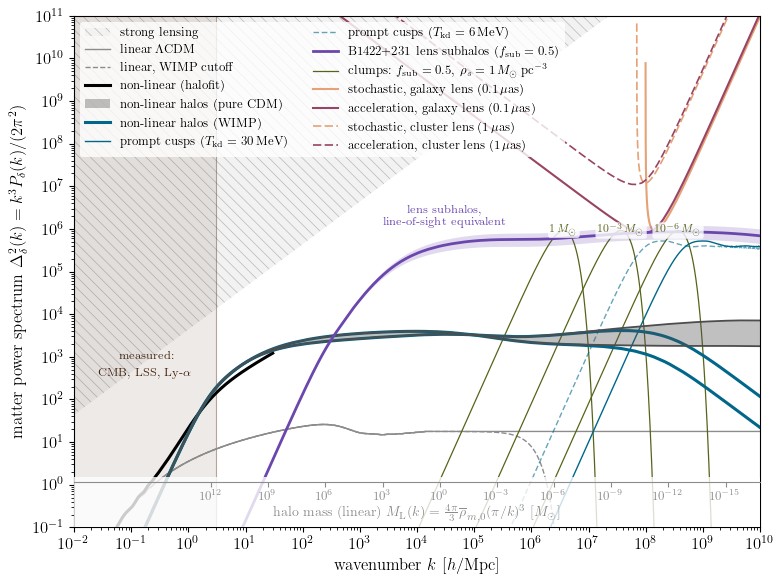

In [25]:
# ---------------------------------------------------------------------------
# figs/matter_power_sub.pdf -- the figure above plus the lens-bound subhalo population.
# The drawing code is a deliberate copy of the Plot cell, so that figs/matter_power.pdf
# stays exactly as it is while this variant is provisional; merge the two (a single
# function with a `subhalos` flag) if the figure is adopted.
# ---------------------------------------------------------------------------
col_sub = (0.42, 0.28, 0.68)     # violet: not used by any other element of this figure

fig,ax = plt.subplots(1,1,figsize=(8,6))

xlim = (1e-2,1e10); ax.set_xlim(xlim);
ylim = (1e-1,1e11); ax.set_ylim(ylim);
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'wavenumber $k~[h/\mathrm{Mpc}]$');
ax.set_ylabel(r'matter power spectrum $\Delta^2_\delta(k) = k^3 P_\delta(k) / (2 \pi^2)$');
ax.set_xticks(np.logspace(np.log10(xlim[0]),np.log10(xlim[1]),1+int(np.log10(xlim[1]/xlim[0]))),minor=False);
ax.set_xticks(np.outer(np.logspace(np.log10(xlim[0]),np.log10(xlim[1])-1,int(np.log10(xlim[1]/xlim[0]))),range(1,10)).flatten(),minor=True);
ax.set_yticks(np.logspace(np.log10(ylim[0]),np.log10(ylim[1]),1+int(np.log10(ylim[1]/ylim[0]))),minor=False);
ax.set_yticks(np.outer(np.logspace(np.log10(ylim[0]),np.log10(ylim[1])-1,int(np.log10(ylim[1]/ylim[0]))),range(1,10)).flatten(),minor=True);

plt.rcParams['hatch.linewidth'] = 0.5
ax.fill_between(k_h_ext, Delta2_strong_lens(kk_ext * Mpc**-1, sys_gal), 1e30, facecolor='0.95',
                edgecolor='0.72', hatch='\\\\\\', lw=0, label=r'strong lensing')

brown = (0.36,0.21,0.11)
ax.axvspan(xlim[0], 3, color=brown + (0.10,), lw=0)
ax.axvline(3, color=brown + (0.45,), lw=0.8, ls='solid')
ax.text(np.sqrt(xlim[0]*3), 3e2, r'measured:\\CMB, LSS, Ly-$\alpha$',
        fontsize=8.5, color=(0.26,0.15,0.07), ha='center', va='bottom')

ax.plot(k_h,     D2_lin,     color='0.55', lw=1, ls='solid')
ax.plot(k_h_ext, D2_lin_ext, color='0.55', lw=1, ls='solid',  label=r'linear $\Lambda$CDM')
ax.plot(k_h_ext, D2_lin_cut, color='0.55', lw=1, ls='dashed', label=r'linear, WIMP cutoff')

ax.plot(k_h_ext[k_h_ext < 30], D2_nl_ext[k_h_ext < 30], color='k', lw=2.2, label=r'non-linear (halofit)')
dark_gray = (0.30,0.30,0.30)
ax.fill_between([], [], [], color=dark_gray, alpha=0.35, lw=0,
                label=r'non-linear halos (pure CDM)')
ax.plot(k_h_ext, D2_nl_PS_lo, color=colors[3],   lw=2.2, zorder=2.2, label=r'non-linear halos (WIMP)')
ax.plot(k_h_ext, D2_nl_PS_hi, color=colors[3],   lw=2.2, zorder=2.2)
ax.plot(k_h_ext, D2_nl_cusp,  color=colors[3],   lw=1,   zorder=2.2,
        label=r'prompt cusps ($T_\mathrm{kd} = 30\,\mathrm{MeV}$)')
ax.plot(k_h_ext, D2_nl_cusp_d, color=colors[3],  lw=1,   zorder=2.2, ls=(0,(4,2)), alpha=0.6,
        label=r'prompt cusps ($T_\mathrm{kd} = %.0f\,\mathrm{MeV}$)' % T_kd_det)
ax.fill_between(k_h_ext, D2_nl_CDM_lo, D2_nl_CDM_hi, color=dark_gray, alpha=0.35, lw=0, zorder=2.4)
ax.plot(k_h_ext, D2_nl_CDM_lo, color=dark_gray,  lw=1.3, zorder=2.4)
ax.plot(k_h_ext, D2_nl_CDM_hi, color=dark_gray,  lw=1.3, zorder=2.4)

# ---- NEW: lens-bound subhalos of B1422+231, as a line-of-sight-equivalent spectrum ----
# Same Sheth-Tormen mass function as the gray band, but with the Moline+2017 subhalo
# concentrations of Fig. SNR and normalized to f_sub kappa^B Sigma_cr rather than to the
# cosmic mean, then rescaled by the slab/line-of-sight signal ratio B (see the cell above).
# The band spans x_sub = 0.1 (lower) to 0.01 (upper), the inner two lines of Fig. SNR.
ax.fill_between(k_h_ext, D2_sub_eq[0.1], D2_sub_eq[0.01], color=col_sub, alpha=0.20, lw=0, zorder=3.0)
ax.plot(k_h_ext, D2_sub_eq[x_sub_lens], color=col_sub, lw=2.0, zorder=3.2,
        label=r'B1422+231 lens subhalos ($f_\mathrm{sub} = %.1f$)' % f_sub_lens)

for M, D2, lab in zip(M_L_clumps, D2_clumps, lab_M_clumps):
    ax.plot(k_h_ext, D2, color=colors[0], lw=0.9)
    i_pk = int(np.argmax(D2))
    ax.text(k_h_ext[i_pk], D2[i_pk], lab, color=colors[0], fontsize=8, zorder=4.6,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.20', facecolor=(1,1,1,0.8), edgecolor='none'))
ax.plot([], [], color=colors[0], lw=0.9,
        label=r'clumps: $f_\mathrm{sub} = 0.5$, $\rho_s = 1\,M_\odot\,\mathrm{pc^{-3}}$')

for s in systems:
    msk_st = s['Delta2_stoch'] > 0
    msk_ac = s['Delta2_acc']   > 0
    lw = 1.5 if s['ls'] == 'solid' else 1.2
    ax.plot(vec_k_stoch[msk_st]/(cosmo.h*Mpc**-1), s['Delta2_stoch'][msk_st],
            color=colors[2], lw=lw, ls=s['ls'])
    ax.plot(vec_k_acc[msk_ac]/(cosmo.h*Mpc**-1),   s['Delta2_acc'][msk_ac],
            color=colors[4], lw=lw, ls=s['ls'])

ax.plot([], [], color=colors[2], lw=1.5, ls='solid',
        label=r'stochastic, galaxy lens ($0.1\,\mathrm{\mu as}$)')
ax.plot([], [], color=colors[4], lw=1.5, ls='solid',
        label=r'acceleration, galaxy lens ($0.1\,\mathrm{\mu as}$)')
ax.plot([], [], color=colors[2], lw=1.2, ls=(0,(5,2)),
        label=r'stochastic, cluster lens ($1\,\mathrm{\mu as}$)')
ax.plot([], [], color=colors[4], lw=1.2, ls=(0,(5,2)),
        label=r'acceleration, cluster lens ($1\,\mathrm{\mu as}$)')

# in-place label for the new curve, on the same translucent white as the clump labels
_i_lab = int(np.argmin(np.abs(k_h_ext - 3e4)))
ax.text(k_h_ext[_i_lab], D2_sub_eq[x_sub_lens][_i_lab]*2.6,
        'lens subhalos,\nline-of-sight equivalent', color=col_sub, fontsize=8.5, zorder=4.6,
        ha='center', va='bottom', linespacing=1.15,
        bbox=dict(boxstyle='round,pad=0.20', facecolor=(1,1,1,0.8), edgecolor='none'))

grey    = '0.55'
_k_unit = cosmo.h * Mpc**-1
def _k2M(k_h):
    k = np.asarray(k_h, float) * _k_unit
    return (4*np.pi/3) * rho_M_0 * (np.pi / k)**3 / M_Solar
def _M2k(M):
    M = np.asarray(M, float) * M_Solar
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.pi / (3*M / (4*np.pi*rho_M_0))**(1/3) / _k_unit
M_exps = np.arange(12, -18, -3)
_y_secax = 0.11
secax  = ax.secondary_xaxis(_y_secax, functions=(_k2M, _M2k))
secax.set_xticks([10.0**e for e in M_exps])
secax.set_xticklabels([r'$10^{%d}$' % e for e in M_exps])
secax.minorticks_off()
secax.set_xlabel(r'halo mass (linear) $M_\mathrm{L}(k) = \frac{4\pi}{3}\overline{\rho}_{m,0} (\pi/k)^3~[M_\odot]$',
                 fontsize=10, color=grey, labelpad=2)
secax.tick_params(colors=grey, labelsize=9)
for _sp in secax.spines.values():
    _sp.set_color(grey)

leg = ax.legend(loc='upper left', frameon=True, framealpha=0.8, facecolor='white',
                edgecolor='none', fontsize=9, ncol=2)
leg.set_zorder(6)
fig.tight_layout()

_pad = 0.010
fig.canvas.draw()
_bb  = secax.get_tightbbox().transformed(ax.transAxes.inverted())
secax.set_location(max(_y_secax - (_bb.y0 - _pad), 0))
fig.canvas.draw()
_bb  = secax.get_tightbbox().transformed(ax.transAxes.inverted())
ax.add_patch(plt.Rectangle((_bb.x0 - _pad, _bb.y0 - _pad), _bb.width + 2*_pad, _bb.height + 2*_pad,
                           transform=ax.transAxes, facecolor=(1,1,1,0.8), edgecolor='none',
                           zorder=4.5))
secax.set_zorder(5)
fig.savefig('../figs/matter_power_sub.pdf', bbox_inches='tight')
print('saved ../figs/matter_power_sub.pdf')